# Tree Segmentation Validation — `ovgu_bbox` @ 250 m

Four quantitative analyses comparing the pipeline output against the Baumkataster (BK):

1. **Crown area** — segmented crown areas vs BK crown areas
2. **Tree heights** — global allometric vs tile-dominant-genus vs BK measured
3. **Match distance & count** — the 15 m threshold, and how the match rate responds to it
4. **Watershed** — for a circle of radius R around each BK tree, how many trees fall inside in the pre-split, post-split and BK sets

In [1]:
import sys, math
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import Circle
from scipy.spatial import cKDTree
from shapely.geometry import box as shapely_box
from pyproj import Transformer

sys.path.insert(0, "..")
from src.config import (AREAS, ALLOMETRIC_PROFILES, ALLOMETRIC_A, ALLOMETRIC_B,
                        CROWN_RADIUS_BY_GENUS, MAX_CROWN_RADIUS_M,
                        BK_MATCH_RADIUS_M, BK_MIN_HEIGHT_M, BK_MIN_CROWN_DIAM_M,
                        BAUMKATASTER_PATH, OUTPUT_DIR)
from src.data_preprocessing import tiles_for_area
from src.shadow.casting import vectorize_trees
from src.shadow.cadastre import tile_dominant_genus

## The datasets

### Dataset 1 - Post-enrichment output (segmentation + the BK join)

### Dataset 2 - Baumkataster (ground truth)

In [2]:
# Dataset 1

TILE_SIZE_VAL = 250   # change to 100 / 500 / 1000 to analyse a different tile size

merged_trees = gpd.read_file(
    OUTPUT_DIR / "segments" / f"{TILE_SIZE_VAL}m" / f"ovgu_bbox_tcd_segformer_trees_merged.fgb"
)
print(f"{len(merged_trees)} polygons \n columns: {list(merged_trees.columns)}\n")
print(f"height_source breakdown:\n{merged_trees['height_source'].value_counts().to_string()}\n")
merged_trees.head(5)

1434 polygons 
 columns: ['tree_id', 'height_m', 'allometric_height_m', 'crown_radius_m', 'crown_area_m2', 'vegetation_model', 'species', 'height_source', 'is_deciduous', 'trunk_circumference_cm', 'planting_year', 'bk_match_dist_m', 'h_global_m', 'geometry']

height_source breakdown:
height_source
allometric    927
measured      507



,tree_id,height_m,allometric_height_m,crown_radius_m,crown_area_m2,vegetation_model,species,height_source,is_deciduous,trunk_circumference_cm,planting_year,bk_match_dist_m,h_global_m,geometry
0,41,8.000000,8.039095,2.000000,13.455953,tcd_segformer,"Tilia cordata, Winterlinde",measured,True,70.0,None,0.5204198973191211,8.530228,"POLYGON ((681495.593 5779639.914, 681495.593 5..."
1,42,5.000000,4.174675,1.500000,2.468381,tcd_segformer,"Tilia cordata, Winterlinde",measured,True,62.0,None,0.8607296544653575,4.974540,"POLYGON ((681487.041 5779639.706, 681487.041 5..."
2,40,18.000000,17.972378,8.000000,140.173461,tcd_segformer,"Populus simonii, Birkenpappel",measured,True,190.0,None,0.9990817276521374,17.972378,"POLYGON ((681403.968 5779652.206, 681403.968 5..."
3,39,11.873385,11.873385,3.390224,36.108264,tcd_segformer,None,allometric,None,None,None,None,11.675749,"POLYGON ((681400.129 5779670.748, 681400.129 5..."
4,38,8.000000,12.773759,3.000000,44.605611,tcd_segformer,"Tilia cordata, Winterlinde",measured,True,100.0,None,0.585974173660797,12.487390,"POLYGON ((681415.661 5779674.081, 681415.661 5..."


In [3]:
# Dataset 2

bk_all   = gpd.read_file(BAUMKATASTER_PATH).to_crs(merged_trees.crs)
print(f"{len(bk_all)} trees \n columns: {list(bk_all.columns)}\n")
bk_all.head(5)

85302 trees 
 columns: ['Gattung lang', 'Stammumfang', 'Baumhoehe', 'Kronendurchmesser', 'Pflanzjahr', 'Objektbezeichnung', 'Objektart lang', 'baumnummer', 'geometry']



,Gattung lang,Stammumfang,Baumhoehe,Kronendurchmesser,Pflanzjahr,Objektbezeichnung,Objektart lang,baumnummer,geometry
0,"Tilia euchlora, Krim-Linde",120.0,14.0,8.0,1950,Zuckerbusch,Öffentliches Grün,1 -G11901,POINT (681809.315 5778107.15)
1,"Tilia cordata, Winterlinde",150.0,17.0,9.0,1930,Zuckerbusch,Öffentliches Grün,2 -G11902,POINT (681810.886 5778102.381)
2,"Tilia cordata, Winterlinde",150.0,13.0,10.0,1930,Zuckerbusch,Öffentliches Grün,3 -G11903,POINT (681816.873 5778109.728)
3,"Tilia cordata, Winterlinde",180.0,18.0,12.0,1930,Zuckerbusch,Öffentliches Grün,5 -G11905,POINT (681824.444 5778112.177)
4,"Tilia cordata, Winterlinde",110.0,13.0,6.0,1950,Zuckerbusch,Öffentliches Grün,6 -G11906,POINT (681826.114 5778107.502)


In [4]:
AREA_KEY   = "ovgu_bbox"
TILE_SIZE  = TILE_SIZE_VAL
MODEL      = "tcd_segformer"
SEG_DIR    = OUTPUT_DIR / f"segments/{TILE_SIZE}m"
MATCH_R    = BK_MATCH_RADIUS_M   # metres — the pipeline's match radius, from config

_to_utm = Transformer.from_crs("EPSG:4326", "EPSG:25832", always_xy=True)

# True tile extents come from tiles_for_area, never from polygon bounds
# (polygon bounds understate the tile whenever no tree touches an edge).
tiles = tiles_for_area(AREAS[AREA_KEY], TILE_SIZE)

def tile_bbox_utm(t):
    """True (minx, miny, maxx, maxy) of a tile in EPSG:25832."""
    minx, miny = _to_utm.transform(t["west"], t["south"])
    maxx, maxy = _to_utm.transform(t["east"], t["north"])
    return minx, miny, maxx, maxy

def seg_path(t):
    return SEG_DIR / f"{AREA_KEY}_tile_{t['ix']}_{t['iy']}_{MODEL}_seg.npy"

# --- Dataset 1, ready for analysis ---
# FlatGeobuf round-trips these columns as strings — coerce before any arithmetic.
merged = merged_trees.copy()
for c in ["bk_match_dist_m", "trunk_circumference_cm", "planting_year"]:
    merged[c] = pd.to_numeric(merged[c], errors="coerce")
merged["genus"] = merged["species"].str.split(",").str[0].str.strip()
matched_mask = merged["height_source"] == "measured"

# --- Dataset 2, clipped to the same extent and filtered exactly as the pipeline
# filters it: same config floors used by enrich_from_baumkataster. ---
b        = merged.total_bounds
bk_area  = bk_all.cx[b[0]:b[2], b[1]:b[3]]
bk_valid = bk_area[(bk_area["Baumhoehe"] > BK_MIN_HEIGHT_M)
                   & (bk_area["Kronendurchmesser"] > BK_MIN_CROWN_DIAM_M)].copy()
bk_valid["bk_crown_area_m2"] = np.pi * (bk_valid["Kronendurchmesser"] / 2) ** 2
bk_valid["genus"] = bk_valid["Gattung lang"].str.split(",").str[0].str.strip()

# --- Tile lookup, shared by every section below ---
# ix increases east, iy increases north, so (ix, iy) indexes a map-oriented grid.
tile_geom = {(t["ix"], t["iy"]): tile_bbox_utm(t) for t in tiles}
TILE_NX = max(k[0] for k in tile_geom) + 1
TILE_NY = max(k[1] for k in tile_geom) + 1
MIN_N_TILE = 5   # below this a per-tile median is noise, not signal

def assign_tile(geom):
    cx, cy = geom.centroid.x, geom.centroid.y
    for key, (minx, miny, maxx, maxy) in tile_geom.items():
        if minx <= cx <= maxx and miny <= cy <= maxy:
            return key
    return None

def to_grid(series):
    """(ix, iy)-keyed Series -> 2-D array, iy as row, ix as column (map-oriented)."""
    g = np.full((TILE_NY, TILE_NX), np.nan)
    for (ix, iy), v in series.items():
        g[iy, ix] = v
    return g

merged["tile"] = merged["geometry"].apply(assign_tile)
bk_valid["tile"] = bk_valid["geometry"].apply(assign_tile)

print(f"Area {AREA_KEY} @ {TILE_SIZE} m — {len(tiles)} tiles ({TILE_NX}×{TILE_NY})")
print(f"  Dataset 1  enriched segmentation : {len(merged):,} polygons")
print(f"  Dataset 2  Baumkataster in bbox  : {len(bk_valid):,} valid trees "
      f"(of {len(bk_area):,} in bbox, {len(bk_all):,} citywide)")
print(f"  BK filters: Baumhoehe > {BK_MIN_HEIGHT_M} m, Kronendurchmesser > {BK_MIN_CROWN_DIAM_M} m; "
      f"match radius {BK_MATCH_RADIUS_M} m")

# h_global_m must be present on every polygon: it depends only on crown_area_m2,
# never on a BK match. Guard against regressing the cadastre.py early-return bug.
assert merged["h_global_m"].notna().all(), (
    f"{merged['h_global_m'].isna().sum()} polygons missing h_global_m — "
    "enrich_from_baumkataster must set it before its early returns"
)
assert merged["tile"].notna().all(), (
    f"{merged['tile'].isna().sum()} polygons fell outside every tile bbox"
)

Area ovgu_bbox @ 250 m — 16 tiles (4×4)
  Dataset 1  enriched segmentation : 1,434 polygons
  Dataset 2  Baumkataster in bbox  : 1,045 valid trees (of 1,060 in bbox, 85,302 citywide)
  BK filters: Baumhoehe > 1.0 m, Kronendurchmesser > 0.5 m; match radius 15.0 m


### Basic analysis of the two datasets

Descriptive statistics before any validation is attempted.

One caveat drives how the tables below are split. The enrichment step **overwrites** `height_m` and
`crown_radius_m` on matched rows with the BK values (`Baumhoehe`, `Kronendurchmesser/2`). So in
Dataset 1:

| Column | Matched rows (507) | Unmatched rows (927) |
|---|---|---|
| `crown_area_m2` | pipeline (pixel count) | pipeline (pixel count) |
| `h_global_m` | pipeline (global allometric) | pipeline (global allometric) |
| `height_m` | **BK measured** | pipeline (allometric) |
| `crown_radius_m` | **BK, `Kronendurchmesser/2`** | pipeline, `sqrt(area/π)` |

Only `crown_area_m2` and `h_global_m` are pipeline-native throughout, so those are the columns to
read as "what the pipeline produced". `height_m` and `crown_radius_m` are reported split by source.

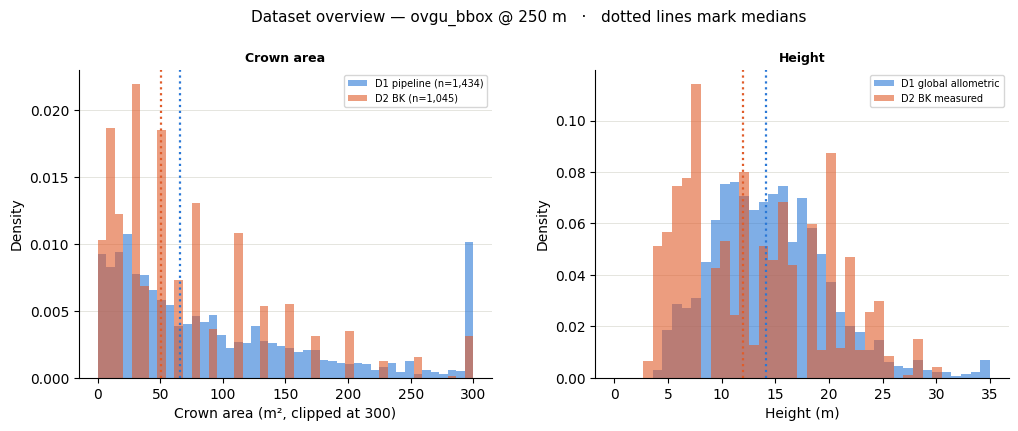

In [5]:
C1, C2 = "#2a78d6", "#e05c2a"   # D1 pipeline, D2 Baumkataster

fig, axes = plt.subplots(1, 2, figsize=(12, 4), gridspec_kw={"wspace": 0.25})

# Panel 1 — crown area
bins = np.linspace(0, 300, 45)
axes[0].hist(merged["crown_area_m2"].clip(0, 300), bins=bins, density=True,
             alpha=0.6, color=C1, label=f"D1 pipeline (n={len(merged):,})")
axes[0].hist(bk_valid["bk_crown_area_m2"].clip(0, 300), bins=bins, density=True,
             alpha=0.6, color=C2, label=f"D2 BK (n={len(bk_valid):,})")
for v, c in [(merged["crown_area_m2"].median(), C1), (bk_valid["bk_crown_area_m2"].median(), C2)]:
    axes[0].axvline(v, color=c, linewidth=1.6, linestyle=":")
axes[0].set_xlabel("Crown area (m², clipped at 300)"); axes[0].set_ylabel("Density")
axes[0].set_title("Crown area", fontsize=9, fontweight="bold"); axes[0].legend(fontsize=7)

# Panel 2 — height
bins = np.linspace(0, 35, 40)
axes[1].hist(merged["h_global_m"].clip(0, 35), bins=bins, density=True,
             alpha=0.6, color=C1, label="D1 global allometric")
axes[1].hist(bk_valid["Baumhoehe"].clip(0, 35), bins=bins, density=True,
             alpha=0.6, color=C2, label="D2 BK measured")
for v, c in [(merged["h_global_m"].median(), C1), (bk_valid["Baumhoehe"].median(), C2)]:
    axes[1].axvline(v, color=c, linewidth=1.6, linestyle=":")
axes[1].set_xlabel("Height (m)"); axes[1].set_ylabel("Density")
axes[1].set_title("Height", fontsize=9, fontweight="bold"); axes[1].legend(fontsize=7)

for ax in axes:
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="y", color="#e1e0d9", linewidth=0.6); ax.set_axisbelow(True)

fig.suptitle(
    f"Dataset overview — {AREA_KEY} @ {TILE_SIZE} m   ·   dotted lines mark medians",
    fontsize=11, y=1.03,
)
plt.show()

### Where each dataset has trees

The histograms above compare the two datasets *distributionally* — they say nothing about **where**
either one sees a tree, and that is where they disagree most. Two reading conventions below:

- **Unmatched polygons are hollow.** A filled polygon found a BK partner within the match radius; a
  hollow one did not, either because BK has no record there or because the geometry did not line up.
- **"no BK" is not 0%.** Tiles with zero BK records are greyed out in panel 2 rather than scored as a
  total match failure — nothing could have matched there.


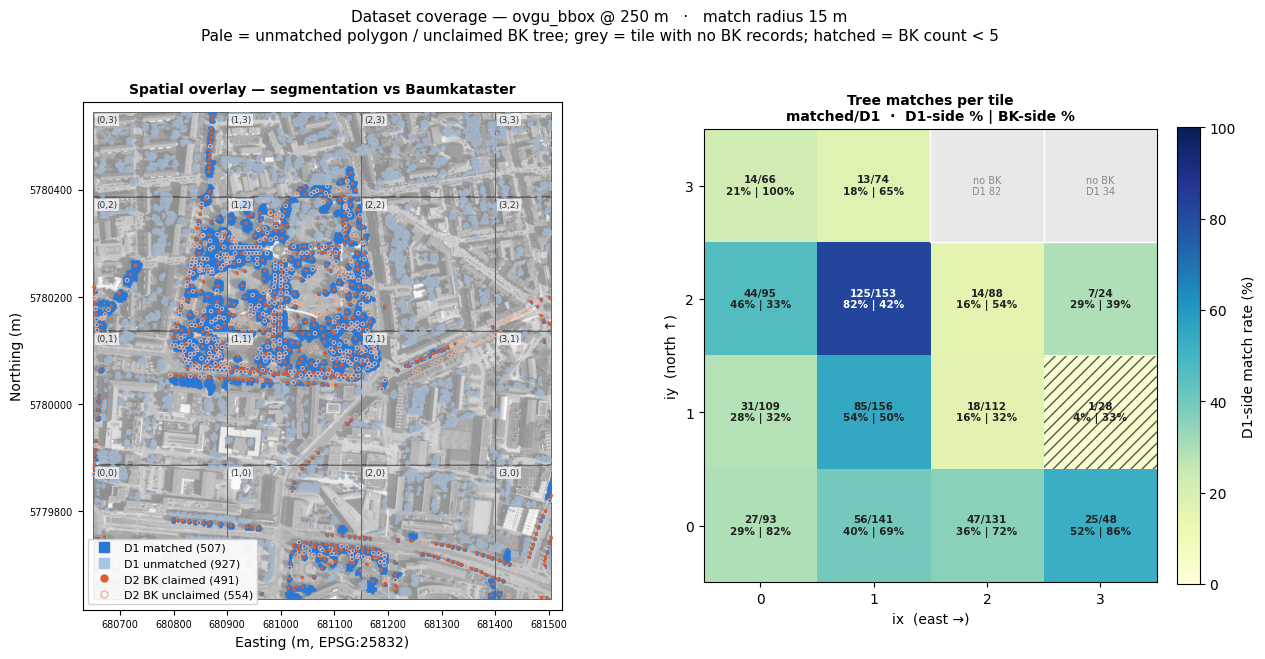

Match rate — 507/1,434 of D1 polygons (35.4%), 507/1,045 of BK trees (48.5%)
  BK trees actually covered: 491/1,045 (47.0%) — 16 polygons share a tree with another polygon
  D1-side  best (1, 2) 82%   worst (3, 1) 4%
  BK-side  best (0, 3) 100%   worst (2, 1) 32%
  no BK coverage: (2, 3), (3, 3) — 116 polygons unmatchable by construction
  densest BK tile (1, 2): 300 BK trees vs 153 polygons (0.51x) — 82% of its polygons matched but only 42% of its BK trees


In [6]:
from PIL import Image

# --- per-tile counts, from the tile labels the setup cell already assigned ---
mdf = pd.DataFrame({
    "d1":      merged.groupby("tile").size(),
    "matched": merged[matched_mask].groupby("tile").size(),
    "bk":      bk_valid.groupby("tile").size(),
}).reindex(sorted(tile_geom)).fillna(0).astype(int)
mdf["rate_d1"] = mdf["matched"] / mdf["d1"].replace(0, np.nan) * 100
mdf["rate_bk"] = mdf["matched"] / mdf["bk"].replace(0, np.nan) * 100   # NaN where BK has no cover

# This panel sits above every validation statistic in the notebook, so it must not be able
# to drift from them.
assert mdf["d1"].sum() == len(merged), "tile counts lost polygons"
assert mdf["matched"].sum() == int(matched_mask.sum()), "tile counts lost matches"
assert mdf["bk"].sum() == len(bk_valid), "tile counts lost BK trees"

fig, axes = plt.subplots(1, 2, figsize=(15, 6.6),
                         gridspec_kw={"width_ratios": [1.15, 1], "wspace": 0.18})

# ---------------------------------------------------------------- panel 1: overlay
ax = axes[0]

# Orthophoto basemap. The pipeline georeferences these rasters with a plain
# from_bounds() over the same UTM rectangle tile_bbox_utm() returns (casting.py
# _bbox_to_transform), so imshow at that extent lands in the polygons' own frame.
ORTHO_DIR = OUTPUT_DIR / AREA_KEY / f"{TILE_SIZE}m"
n_basemap = 0
for t in tiles:
    p = ORTHO_DIR / f"{AREA_KEY}_tile_{t['ix']}_{t['iy']}.png"
    if not p.exists():
        continue                      # degrade to no basemap rather than raise
    img = Image.open(p).convert("L").resize((300, 300), Image.BILINEAR)
    minx, miny, maxx, maxy = tile_bbox_utm(t)
    ax.imshow(np.asarray(img), extent=(minx, maxx, miny, maxy), origin="upper",
              cmap="gray", alpha=0.45, zorder=0)
    n_basemap += 1

# Which BK trees were actually claimed? enrich_from_baumkataster drops index_right,
# but bk_match_dist_m pins the partner exactly: among the nearest BK points to a
# matched polygon's centroid, the partner is the one at precisely that distance.
bk_xy = np.array([[g.x, g.y] for g in bk_valid.geometry])
cen   = np.array([[g.centroid.x, g.centroid.y]
                  for g in merged.loc[matched_mask, "geometry"]])
_d, _i = cKDTree(bk_xy).query(cen, k=8)
_target = merged.loc[matched_mask, "bk_match_dist_m"].to_numpy(dtype=float)
_pick   = np.abs(_d - _target[:, None]).argmin(axis=1)
_rows   = np.arange(len(_d))
assert (np.abs(_d[_rows, _pick] - _target) < 1e-6).all(), \
    "some matched polygons could not be traced back to a BK tree"
bk_claimed = np.zeros(len(bk_valid), dtype=bool)
bk_claimed[_i[_rows, _pick]] = True

# D1 polygons. Unmatched outnumbers matched ~2:1, so it gets a light fill rather than
# a bare outline — an outline recedes so far it reads as empty ground.
C1_PALE, C2_PALE = "#a8c4e4", "#f0b49a"
merged[~matched_mask].plot(ax=ax, facecolor=C1_PALE, edgecolor=C1_PALE, linewidth=0.4,
                           alpha=0.60, zorder=2)
merged[matched_mask].plot(ax=ax, facecolor=C1, edgecolor=C1, linewidth=0.4, zorder=3)

# D2 Baumkataster points, split the same way: hollow = no polygon claimed this tree
ax.scatter(bk_valid.geometry.x[~bk_claimed], bk_valid.geometry.y[~bk_claimed], s=7,
           facecolor="none", edgecolor=C2_PALE, linewidths=0.7, zorder=4)
ax.scatter(bk_valid.geometry.x[bk_claimed], bk_valid.geometry.y[bk_claimed], s=6,
           color=C2, edgecolor="none", zorder=5)

# Tile boundaries
for (ix, iy), (minx, miny, maxx, maxy) in tile_geom.items():
    ax.add_patch(plt.Rectangle((minx, miny), maxx - minx, maxy - miny, fill=False,
                               edgecolor="#666666", linewidth=0.7, zorder=1))
    ax.text(minx + 6, maxy - 6, f"({ix},{iy})", fontsize=6.5, color="#333333",
            ha="left", va="top", zorder=5,
            bbox=dict(boxstyle="square,pad=0.15", fc="white", ec="none", alpha=0.7))

handles = [
    plt.Line2D([], [], marker="s", linestyle="none", markerfacecolor=C1,
               markeredgecolor=C1, markersize=7,
               label=f"D1 matched ({int(matched_mask.sum()):,})"),
    plt.Line2D([], [], marker="s", linestyle="none", markerfacecolor=C1_PALE,
               markeredgecolor=C1_PALE, markersize=7,
               label=f"D1 unmatched ({int((~matched_mask).sum()):,})"),
    plt.Line2D([], [], marker="o", linestyle="none", color=C2, markersize=5,
               label=f"D2 BK claimed ({int(bk_claimed.sum()):,})"),
    plt.Line2D([], [], marker="o", linestyle="none", markerfacecolor="none",
               markeredgecolor=C2_PALE, markersize=5,
               label=f"D2 BK unclaimed ({int((~bk_claimed).sum()):,})"),
]
ax.legend(handles=handles, fontsize=8, loc="lower left", framealpha=0.9)
ax.set_aspect("equal")
b = merged.total_bounds
ax.set_xlim(b[0] - 20, b[2] + 20); ax.set_ylim(b[1] - 20, b[3] + 20)
ax.set_xlabel("Easting (m, EPSG:25832)"); ax.set_ylabel("Northing (m)")
ax.set_title(f"Spatial overlay — segmentation vs Baumkataster"
             f"{'' if n_basemap else '  (orthophoto unavailable)'}",
             fontsize=10, fontweight="bold")
ax.ticklabel_format(style="plain", useOffset=False)
ax.tick_params(labelsize=7)

# ---------------------------------------------------------------- panel 2: match heatmap
ax = axes[1]
rate_grid = to_grid(mdf["rate_d1"])
im = ax.imshow(rate_grid, origin="lower", cmap="YlGnBu", vmin=0, vmax=100)

grids = {k: to_grid(mdf[k]) for k in ["d1", "matched", "bk", "rate_bk"]}
for iy in range(TILE_NY):
    for ix in range(TILE_NX):
        d1, mt, bk = (int(grids[k][iy, ix]) for k in ["d1", "matched", "bk"])
        if bk == 0:      # nothing could have matched here — not a failure
            ax.add_patch(plt.Rectangle((ix - .5, iy - .5), 1, 1,
                                       facecolor="#e8e8e8", edgecolor="white"))
            ax.text(ix, iy, f"no BK\nD1 {d1}", ha="center", va="center",
                    fontsize=7, color="#888888")
            continue
        if bk < MIN_N_TILE:   # BK-side rate is noise on a handful of records
            ax.add_patch(plt.Rectangle((ix - .5, iy - .5), 1, 1, fill=False,
                                       hatch="///", edgecolor="#555555", linewidth=0))
        r1, r2 = rate_grid[iy, ix], grids["rate_bk"][iy, ix]
        ax.text(ix, iy, f"{mt}/{d1}\n{r1:.0f}% | {r2:.0f}%", ha="center", va="center",
                fontsize=7.5, fontweight="bold",
                color="white" if r1 > 55 else "#222222")

ax.set_xticks(range(TILE_NX)); ax.set_yticks(range(TILE_NY))
ax.set_xlabel("ix  (east →)"); ax.set_ylabel("iy  (north ↑)")
ax.set_title("Tree matches per tile\nmatched/D1  ·  D1-side % | BK-side %",
             fontsize=10, fontweight="bold")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="D1-side match rate (%)")

fig.suptitle(
    f"Dataset coverage — {AREA_KEY} @ {TILE_SIZE} m   ·   match radius {MATCH_R:.0f} m\n"
    f"Pale = unmatched polygon / unclaimed BK tree; grey = tile with no BK records; "
    f"hatched = BK count < {MIN_N_TILE}",
    fontsize=11, y=1.02,
)
plt.show()

# ---------------------------------------------------------------- summary
# Read through plain dicts: a DataFrame indexed by (ix, iy) tuples cannot be
# addressed with .loc[key, col] — pandas unpacks the tuple as a (row, col) pair.
n_m = int(matched_mask.sum())
print(f"Match rate — {n_m}/{len(merged):,} of D1 polygons ({n_m/len(merged)*100:.1f}%), "
      f"{n_m}/{len(bk_valid):,} of BK trees ({n_m/len(bk_valid)*100:.1f}%)")
# A BK tree may be claimed by more than one polygon, so matched/BK overstates coverage.
n_c = int(bk_claimed.sum())
print(f"  BK trees actually covered: {n_c}/{len(bk_valid):,} ({n_c/len(bk_valid)*100:.1f}%) — "
      f"{n_m - n_c} polygons share a tree with another polygon")

has_bk = mdf[mdf["bk"] > 0]
cols = {c: has_bk[c].to_dict() for c in ["d1", "matched", "bk", "rate_d1", "rate_bk"]}
for side, key in [("D1-side", "rate_d1"), ("BK-side", "rate_bk")]:
    r = cols[key]
    hi, lo = max(r, key=r.get), min(r, key=r.get)
    print(f"  {side}  best {hi} {r[hi]:.0f}%   worst {lo} {r[lo]:.0f}%")

d1_of = mdf["d1"].to_dict()
no_bk = [k for k, v in mdf["bk"].to_dict().items() if v == 0]
print(f"  no BK coverage: {', '.join(str(k) for k in no_bk)} — "
      f"{sum(d1_of[k] for k in no_bk)} polygons unmatchable by construction")

# The two datasets disagree about tree *count* per tile far more than about tree size.
k = max(cols["bk"], key=cols["bk"].get)
print(f"  densest BK tile {k}: {cols['bk'][k]} BK trees vs {cols['d1'][k]} polygons "
      f"({cols['d1'][k]/cols['bk'][k]:.2f}x) — {cols['rate_d1'][k]:.0f}% of its polygons matched "
      f"but only {cols['rate_bk'][k]:.0f}% of its BK trees")

## 1 · Crown area comparison

For matched trees the BK crown radius is already stored in `crown_radius_m` (the enrichment step
overwrites it with `Kronendurchmesser/2`), so the BK crown area is exactly `π · crown_radius_m²` —
no re-matching needed. `crown_area_m2` remains the pipeline's own pixel-derived area.

In [7]:
matched = merged[matched_mask].dropna(subset=["crown_area_m2", "crown_radius_m"]).copy()
# BK crown area straight from the pipeline's own match (see markdown above)
matched["bk_crown_area_m2"] = np.pi * matched["crown_radius_m"] ** 2
ratio = matched["crown_area_m2"] / matched["bk_crown_area_m2"]

d1_m, d2_m = matched["crown_area_m2"], matched["bk_crown_area_m2"]

summary = pd.DataFrame([
    {"scope": "matched (paired)", "dataset": "D1 pipeline",   "n": len(d1_m),
     "total_m2": d1_m.sum(), "median_m2": d1_m.median(), "mean_m2": d1_m.mean()},
    {"scope": "matched (paired)", "dataset": "D2 Baumkataster", "n": len(d2_m),
     "total_m2": d2_m.sum(), "median_m2": d2_m.median(), "mean_m2": d2_m.mean()},
    {"scope": "all (unpaired)",   "dataset": "D1 pipeline",   "n": len(merged),
     "total_m2": merged["crown_area_m2"].sum(), "median_m2": merged["crown_area_m2"].median(),
     "mean_m2": merged["crown_area_m2"].mean()},
    {"scope": "all (unpaired)",   "dataset": "D2 Baumkataster", "n": len(bk_valid),
     "total_m2": bk_valid["bk_crown_area_m2"].sum(), "median_m2": bk_valid["bk_crown_area_m2"].median(),
     "mean_m2": bk_valid["bk_crown_area_m2"].mean()},
])
print("Crown area (CPA) — total and median, both datasets")
print(summary.to_string(index=False, float_format=lambda v: f"{v:,.1f}"))

print("\nD1 / D2 ratios")
print(f"  matched — total  {d1_m.sum() / d2_m.sum():5.2f}x     median {d1_m.median() / d2_m.median():5.2f}x")
print(f"  all     — total  {merged['crown_area_m2'].sum() / bk_valid['bk_crown_area_m2'].sum():5.2f}x"
      f"     median {merged['crown_area_m2'].median() / bk_valid['bk_crown_area_m2'].median():5.2f}x")

# The total and the median disagree by ~4x. Merged blobs are why: they are a
# minority of polygons but hold nearly all of the segmented area.
blob = matched["crown_area_m2"] > 200
print(f"\nWhy total and median disagree — merged blobs (CPA > 200 m²)")
print(f"  {blob.sum()} of {len(matched)} matched polygons ({blob.mean()*100:.1f}%)")
print(f"  hold {matched.loc[blob, 'crown_area_m2'].sum() / d1_m.sum() * 100:.1f}% of D1's matched total area")
print(f"  excluding them: total ratio {matched.loc[~blob, 'crown_area_m2'].sum() / matched.loc[~blob, 'bk_crown_area_m2'].sum():.2f}x, "
      f"median ratio {(matched.loc[~blob, 'crown_area_m2'] / matched.loc[~blob, 'bk_crown_area_m2']).median():.2f}x")

print(f"\nPer-tree ratio (D1/D2): median {ratio.median():.2f}   "
      f"ratio > 2 for {(ratio > 2).sum()} trees ({(ratio > 2).mean()*100:.1f}%)")

Crown area (CPA) — total and median, both datasets
           scope         dataset    n  total_m2  median_m2  mean_m2
matched (paired)     D1 pipeline  507  78,832.7       83.0    155.5
matched (paired) D2 Baumkataster  507  41,315.3       50.3     81.5
  all (unpaired)     D1 pipeline 1434 160,531.5       65.7    111.9
  all (unpaired) D2 Baumkataster 1045  70,721.3       50.3     67.7

D1 / D2 ratios
  matched — total   1.91x     median  1.65x
  all     — total   2.27x     median  1.31x

Why total and median disagree — merged blobs (CPA > 200 m²)
  106 of 507 matched polygons (20.9%)
  hold 63.4% of D1's matched total area
  excluding them: total ratio 1.11x, median ratio 1.05x

Per-tree ratio (D1/D2): median 1.19   ratio > 2 for 115 trees (22.7%)


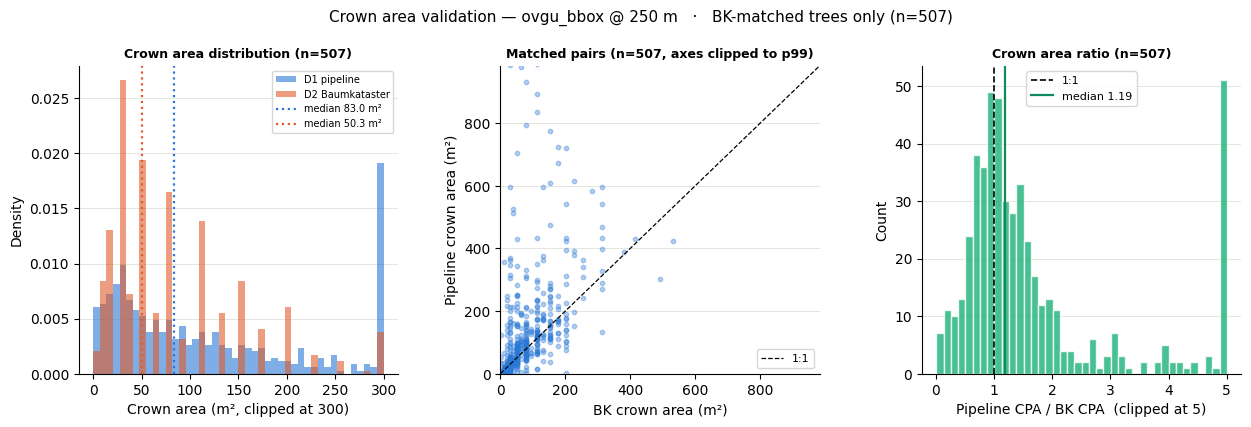

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), gridspec_kw={"wspace": 0.32})

# Panel 1 — paired crown-area distributions (same 274 trees in both series)
bins = np.linspace(0, 300, 45)
axes[0].hist(matched["crown_area_m2"].clip(0, 300), bins=bins, density=True,
             alpha=0.6, color=C1, label="D1 pipeline")
axes[0].hist(matched["bk_crown_area_m2"].clip(0, 300), bins=bins, density=True,
             alpha=0.6, color=C2, label="D2 Baumkataster")
axes[0].axvline(matched["crown_area_m2"].median(), color=C1, linewidth=1.6, linestyle=":",
                label=f"median {matched['crown_area_m2'].median():.1f} m²")
axes[0].axvline(matched["bk_crown_area_m2"].median(), color=C2, linewidth=1.6, linestyle=":",
                label=f"median {matched['bk_crown_area_m2'].median():.1f} m²")
axes[0].set_xlabel("Crown area (m², clipped at 300)"); axes[0].set_ylabel("Density")
axes[0].set_title(f"Crown area distribution (n={len(matched):,})", fontsize=9, fontweight="bold")
axes[0].legend(fontsize=7)

# Panel 2 — matched-pair scatter
lim = float(np.nanpercentile(
    np.concatenate([matched["bk_crown_area_m2"], matched["crown_area_m2"]]), 99))
axes[1].scatter(matched["bk_crown_area_m2"], matched["crown_area_m2"],
                alpha=0.35, s=10, color=C1)
axes[1].plot([0, lim], [0, lim], "k--", linewidth=0.9, label="1:1")
axes[1].set_xlim(0, lim); axes[1].set_ylim(0, lim)
axes[1].set_xlabel("BK crown area (m²)"); axes[1].set_ylabel("Pipeline crown area (m²)")
axes[1].set_title(f"Matched pairs (n={len(matched):,}, axes clipped to p99)",
                  fontsize=9, fontweight="bold")
axes[1].legend(fontsize=8)

# Panel 3 — ratio histogram
axes[2].hist(ratio.clip(0, 5), bins=40, color="#1baf7a", alpha=0.8, edgecolor="white")
axes[2].axvline(1.0, color="black", linestyle="--", linewidth=1.2, label="1:1")
axes[2].axvline(ratio.median(), color="#118a5e", linewidth=1.6,
                label=f"median {ratio.median():.2f}")
axes[2].set_xlabel("Pipeline CPA / BK CPA  (clipped at 5)"); axes[2].set_ylabel("Count")
axes[2].set_title(f"Crown area ratio (n={len(ratio):,})", fontsize=9, fontweight="bold")
axes[2].legend(fontsize=8)

for ax in axes:
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="y", color="#e1e0d9", linewidth=0.6); ax.set_axisbelow(True)

fig.suptitle(
    f"Crown area validation — {AREA_KEY} @ {TILE_SIZE} m   ·   "
    f"BK-matched trees only (n={len(matched):,})",
    fontsize=11, y=1.02,
)
plt.show()

### Crown area per tile

The same total / median comparison broken down by tile, on the matched trees only.
`ix` increases east and `iy` increases north, so the heatmaps read as a map of the area.

Two caveats when reading the per-tile numbers:

- **Small samples.** Matched trees are unevenly spread (1 to 52 per tile). Tiles with fewer than
  5 matched trees are hatched — their medians and ratios are noise.
- **Two tiles have no matched trees at all** — (2,3) and (3,3), the same pair that exposed the
  `h_global_m` early-return bug. They render blank, not zero.

Crown area per tile — BK-matched trees only
         n  d1_total  d1_median  d2_total  d2_median  total_ratio  median_ratio
(0,0)   27   1,725.9       67.4   1,535.5       50.3          1.1           1.3
(0,1)   31   7,228.2       75.0   1,386.2       28.3          5.2           2.7
(0,2)   44  12,997.4      185.5   6,485.8      122.9          2.0           1.5
(0,3)   14   1,490.7       93.0   1,095.6       78.5          1.4           1.2
(1,0)   56   5,491.2       84.0   3,996.1       50.3          1.4           1.7
(1,1)   85  12,763.0       91.3   6,664.1       78.5          1.9           1.2
(1,2)  125  25,282.9      128.3  13,265.4      113.1          1.9           1.1
(1,3)   13   1,964.4       91.0   1,322.8       95.0          1.5           1.0
(2,0)   47   3,403.4       32.9   2,273.7       38.5          1.5           0.9
(2,1)   18   2,900.0       51.2   1,156.1       28.3          2.5           1.8
(2,2)   14   1,971.2      129.8   1,167.9       63.6          1.7           

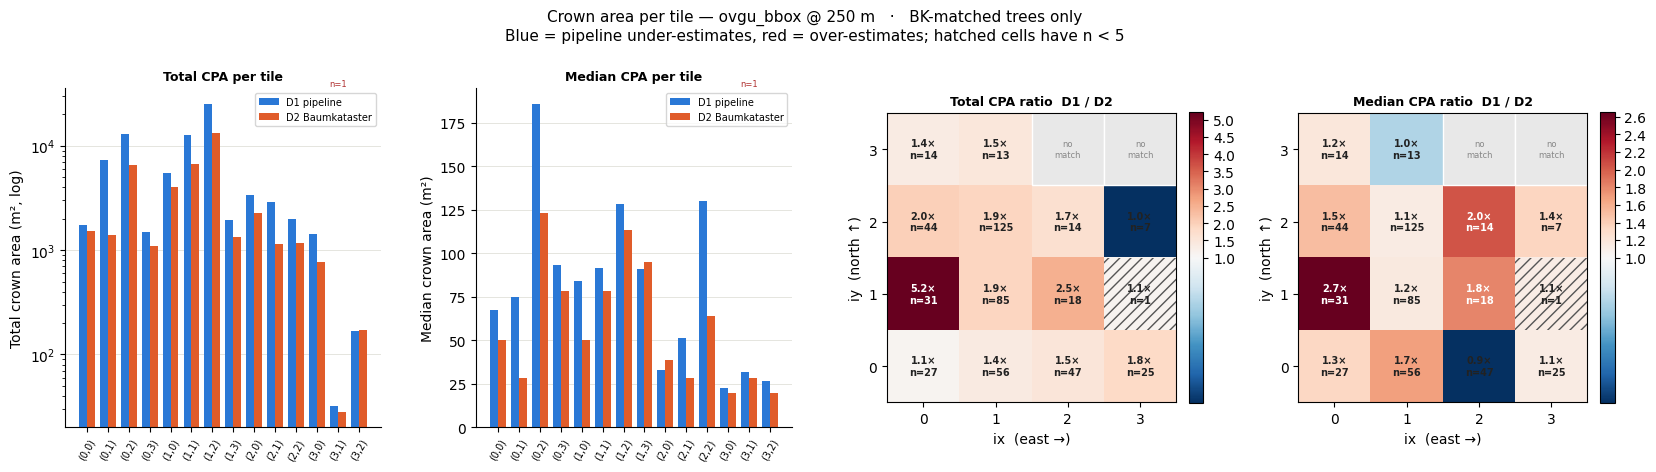

In [9]:
tdf = (matched.groupby("tile")
       .agg(n=("crown_area_m2", "size"),
            d1_total=("crown_area_m2", "sum"),   d1_median=("crown_area_m2", "median"),
            d2_total=("bk_crown_area_m2", "sum"), d2_median=("bk_crown_area_m2", "median"))
       .reindex(sorted(tile_geom)))          # every tile, even those with no matches
tdf["total_ratio"]  = tdf["d1_total"]  / tdf["d2_total"]
tdf["median_ratio"] = tdf["d1_median"] / tdf["d2_median"]
tdf["n"] = tdf["n"].fillna(0).astype(int)

disp = tdf.copy()
disp.index = [f"({x},{y})" for x, y in disp.index]
print("Crown area per tile — BK-matched trees only")
print(disp.to_string(float_format=lambda v: f"{v:,.1f}", na_rep="—"))
print(f"\nTiles with matches: {(tdf['n'] > 0).sum()} of {len(tdf)}   "
      f"below n={MIN_N_TILE}: {((tdf['n'] > 0) & (tdf['n'] < MIN_N_TILE)).sum()}")
print(f"Column totals — D1 {tdf['d1_total'].sum():,.0f} m²   D2 {tdf['d2_total'].sum():,.0f} m²   "
      f"(matches the headline {d1_m.sum():,.0f} / {d2_m.sum():,.0f})")

# ---------------------------------------------------------------- figure
from matplotlib.colors import TwoSlopeNorm

have = tdf[tdf["n"] > 0]
labels = [f"({x},{y})" for x, y in have.index]
x = np.arange(len(have)); w = 0.38

fig, axes = plt.subplots(1, 4, figsize=(20, 4.4), gridspec_kw={"wspace": 0.30})

# Panel 1 — total CPA per tile (log: spans 32 m² to 26,400 m²)
axes[0].bar(x - w/2, have["d1_total"], w, color=C1, label="D1 pipeline")
axes[0].bar(x + w/2, have["d2_total"], w, color=C2, label="D2 Baumkataster")
axes[0].set_yscale("log")
axes[0].set_xticks(x); axes[0].set_xticklabels(labels, rotation=60, fontsize=7)
axes[0].set_ylabel("Total crown area (m², log)")
axes[0].set_title("Total CPA per tile", fontsize=9, fontweight="bold")
axes[0].legend(fontsize=7)

# Panel 2 — median CPA per tile
axes[1].bar(x - w/2, have["d1_median"], w, color=C1, label="D1 pipeline")
axes[1].bar(x + w/2, have["d2_median"], w, color=C2, label="D2 Baumkataster")
axes[1].set_xticks(x); axes[1].set_xticklabels(labels, rotation=60, fontsize=7)
axes[1].set_ylabel("Median crown area (m²)")
axes[1].set_title("Median CPA per tile", fontsize=9, fontweight="bold")
axes[1].legend(fontsize=7)

for ax in axes[:2]:
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="y", color="#e1e0d9", linewidth=0.6); ax.set_axisbelow(True)
    for xi, nv in zip(x, have["n"]):
        if nv < MIN_N_TILE:
            ax.annotate(f"n={nv}", (xi, 1), xycoords=("data", "axes fraction"),
                        ha="center", va="bottom", fontsize=6, color="#b03030")

# Panels 3-4 — spatial heatmaps of the two ratios
n_grid = to_grid(tdf["n"])
for ax, col, title in [(axes[2], "total_ratio",  "Total CPA ratio  D1 / D2"),
                       (axes[3], "median_ratio", "Median CPA ratio  D1 / D2")]:
    grid = to_grid(tdf[col])
    finite = grid[np.isfinite(grid)]
    vmax = max(float(finite.max()), 1.01) if finite.size else 2.0
    vmin = min(float(finite.min()), 0.99) if finite.size else 0.5
    im = ax.imshow(grid, origin="lower", cmap="RdBu_r",
                   norm=TwoSlopeNorm(vmin=vmin, vcenter=1.0, vmax=vmax))
    for iy in range(TILE_NY):
        for ix in range(TILE_NX):
            v, nv = grid[iy, ix], n_grid[iy, ix]
            if not np.isfinite(v):
                ax.add_patch(plt.Rectangle((ix - .5, iy - .5), 1, 1,
                                           facecolor="#e8e8e8", edgecolor="white"))
                ax.text(ix, iy, "no\nmatch", ha="center", va="center",
                        fontsize=6, color="#888888")
                continue
            if nv < MIN_N_TILE:   # mark low-confidence cells
                ax.add_patch(plt.Rectangle((ix - .5, iy - .5), 1, 1, fill=False,
                                           hatch="///", edgecolor="#555555", linewidth=0))
            ax.text(ix, iy, f"{v:.1f}×\nn={int(nv)}", ha="center", va="center",
                    fontsize=7, fontweight="bold",
                    color="white" if abs(v - 1) > (vmax - 1) * 0.45 else "#222222")
    ax.set_xticks(range(TILE_NX)); ax.set_yticks(range(TILE_NY))
    ax.set_xlabel("ix  (east →)"); ax.set_ylabel("iy  (north ↑)")
    ax.set_title(title, fontsize=9, fontweight="bold")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

fig.suptitle(
    f"Crown area per tile — {AREA_KEY} @ {TILE_SIZE} m   ·   BK-matched trees only\n"
    f"Blue = pipeline under-estimates, red = over-estimates; hatched cells have n < {MIN_N_TILE}",
    fontsize=11, y=1.06,
)
plt.show()

## 2 · Height comparison: global vs tile-dominant genus vs BK

Three predictions are compared against the BK measured height on matched trees:

| Model | (A, B) source |
|---|---|
| **Global** | `ALLOMETRIC_A/B` = (1.317, 0.318), same for every tree |
| **Tile-dominant** | the modal BK genus in the tile, via `tile_dominant_genus()` |
| **Per-species** | each tree's own BK species (already in `allometric_height_m`) |

The tile-dominant lookup must use `tile_dominant_genus()`, which strips the German name after the
comma — `ALLOMETRIC_PROFILES` is keyed on the bare binomial, so a raw `Gattung lang` value would
never match and would silently collapse onto the global model.

In [10]:
# Tile-dominant genus per tile — tile_geom / assign_tile come from the setup cell,
# and merged["tile"] is already populated there.
tile_genus = {}
for key, (minx, miny, maxx, maxy) in tile_geom.items():
    bk_tile = bk_valid.cx[minx:maxx, miny:maxy]
    tile_genus[key] = tile_dominant_genus(bk_tile) if len(bk_tile) else None

matched2 = merged[matched_mask].dropna(
    subset=["height_m", "h_global_m", "allometric_height_m", "crown_area_m2"]
).copy()
matched2 = matched2[matched2["height_m"] > 1]

def dominant_height(row):
    genus = tile_genus.get(row["tile"])
    A, B = ALLOMETRIC_PROFILES.get(genus, (ALLOMETRIC_A, ALLOMETRIC_B))
    return math.exp(A + B * math.log(max(row["crown_area_m2"], 1e-6)))

matched2["h_tile_dominant_m"] = matched2.apply(dominant_height, axis=1)

print("Tile-dominant genus per tile:")
for key in sorted(tile_genus):
    g = tile_genus[key]
    hit = "profile" if g in ALLOMETRIC_PROFILES else "global fallback"
    print(f"  {str(key):8s} {str(g):32s} [{hit}]")

print(f"\nMatched trees for height analysis: {len(matched2):,}\n")
print(f"  {'Model':16s} {'mean':>9s} {'median':>9s} {'std':>9s} {'|dev|>20%':>10s}")
for col, label in [("h_global_m", "Global"),
                   ("h_tile_dominant_m", "Tile-dominant"),
                   ("allometric_height_m", "Per-species")]:
    dev = (matched2[col] - matched2["height_m"]) / matched2["height_m"] * 100
    print(f"  {label:16s} {dev.mean():+8.1f}% {dev.median():+8.1f}% {dev.std():8.1f}% "
          f"{(dev.abs() > 20).mean()*100:9.1f}%")

Tile-dominant genus per tile:
  (0, 0)   Platanus acerifolia              [profile]
  (0, 1)   Tilia euchlora                   [profile]
  (0, 2)   Quercus robur                    [profile]
  (0, 3)   Populus simonii                  [global fallback]
  (1, 0)   Tilia cordata                    [profile]
  (1, 1)   Tilia euchlora                   [profile]
  (1, 2)   Tilia cordata                    [profile]
  (1, 3)   Quercus robur                    [profile]
  (2, 0)   Tilia cordata                    [profile]
  (2, 1)   Sorbus intermedia                [profile]
  (2, 2)   Robinia pseudoacacia             [profile]
  (2, 3)   None                             [global fallback]
  (3, 0)   Acer platanoides                 [profile]
  (3, 1)   Sorbus thuringiaca 'Fastigiata'  [global fallback]
  (3, 2)   Amelanchier lamarckii            [global fallback]
  (3, 3)   None                             [global fallback]

Matched trees for height analysis: 507

  Model                 m

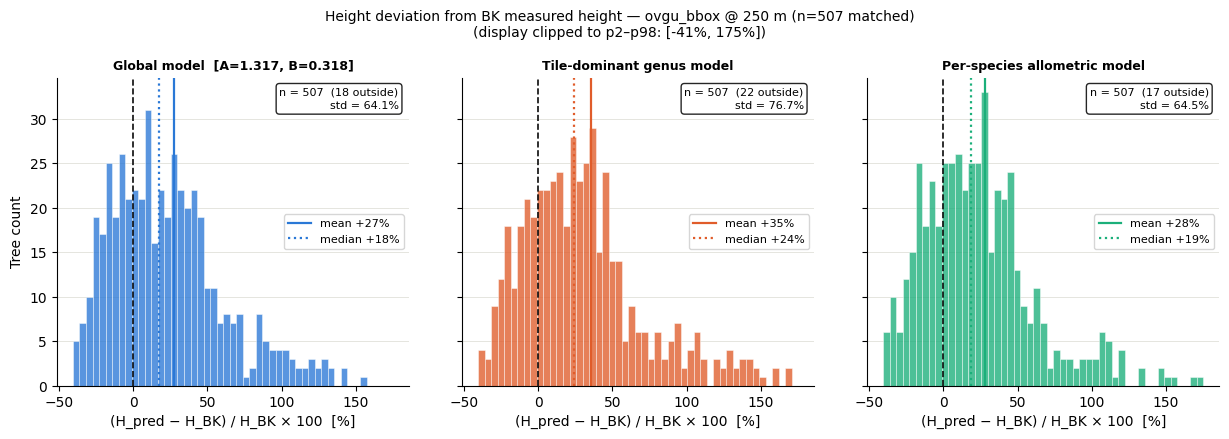

In [11]:
pairs = [
    ("h_global_m",          f"Global model  [A={ALLOMETRIC_A}, B={ALLOMETRIC_B}]", "#2a78d6"),
    ("h_tile_dominant_m",   "Tile-dominant genus model",                           "#e05c2a"),
    ("allometric_height_m", "Per-species allometric model",                        "#1baf7a"),
]
devs = {c: (matched2[c] - matched2["height_m"]) / matched2["height_m"] * 100 for c, *_ in pairs}
lo   = min(np.percentile(d, 2)  for d in devs.values())
hi   = max(np.percentile(d, 98) for d in devs.values())
bins = np.linspace(lo, hi, 50)

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True, gridspec_kw={"wspace": 0.15})
for ax, (col, label, color) in zip(axes, pairs):
    dev = devs[col]
    ax.hist(dev, bins=bins, color=color, alpha=0.78, edgecolor="white", linewidth=0.4)
    ax.axvline(0, color="#0b0b0b", linewidth=1.2, linestyle="--")
    ax.axvline(dev.mean(),   color=color, linewidth=1.6, linestyle="-", label=f"mean {dev.mean():+.0f}%")
    ax.axvline(dev.median(), color=color, linewidth=1.6, linestyle=":", label=f"median {dev.median():+.0f}%")
    n_out = int(((dev < lo) | (dev > hi)).sum())
    ax.set_title(label, fontsize=9, fontweight="bold")
    ax.set_xlabel("(H_pred − H_BK) / H_BK × 100  [%]")
    ax.legend(fontsize=8)
    ax.text(0.97, 0.97, f"n = {len(dev):,}  ({n_out} outside)\nstd = {dev.std():.1f}%",
            transform=ax.transAxes, va="top", ha="right", fontsize=8, linespacing=1.5,
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.85))
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="y", color="#e1e0d9", linewidth=0.6); ax.set_axisbelow(True)
axes[0].set_ylabel("Tree count")

fig.suptitle(
    f"Height deviation from BK measured height — {AREA_KEY} @ {TILE_SIZE} m "
    f"(n={len(matched2):,} matched)\n(display clipped to p2–p98: [{lo:.0f}%, {hi:.0f}%])",
    fontsize=10, y=1.05,
)
plt.show()

### Height deviation per tile

The pooled table above says the **tile-dominant model is worse than the global model** it was meant
to improve on (+35.4% vs +30.6% median). The per-tile view shows where that comes from.

Metric is the median of `(H_pred − H_BK) / H_BK × 100` within each tile — median rather than mean,
because the blob-inflated crowns skew the mean badly (tile (1,2): median +23% vs mean +100%).

The last panel is the decision one: **improvement = |global| − |tile-dominant|** in percentage
points, so green means the tile-dominant model got closer to the measured height.

Three things to read carefully:

- **Genus-fallback tiles (†)** have a dominant genus that is absent from `ALLOMETRIC_PROFILES`, so
  `dominant_height()` falls back to the global (A, B) coefficients. Their two models are
  *identical by construction* — a zero improvement there means "not attempted", not "no effect".
- **Hatched cells** have `n < 5` matched trees; their medians are noise.
- Tiles (2,3) and (3,3) have no matched trees and render blank.

Height deviation per tile (%) — BK-matched trees only, median unless stated
         n                 dom_genus  fallback  med_global  med_tiledom  med_species  mean_global  mean_tiledom  improve_pp
(2,1)   18         Sorbus intermedia     False        49.0         10.7         10.7         48.1           7.9        38.3
(2,0)   47             Tilia cordata     False        36.4         35.5         35.5         33.8          37.5         0.9
(0,3)   14           Populus simonii      True        -9.2         -9.2        -11.7         -4.7          -4.7         0.0
(3,1)    1  Sorbus thuringiaca 'Fast      True       180.6        180.6        180.6        180.6         180.6         0.0
(3,2)    7     Amelanchier lamarckii      True        51.6         51.6         49.7         56.1          56.1         0.0
(1,1)   85            Tilia euchlora     False        -6.6          8.3          2.3          9.6          24.7        -1.7
(0,0)   27       Platanus acerifolia     False        -3

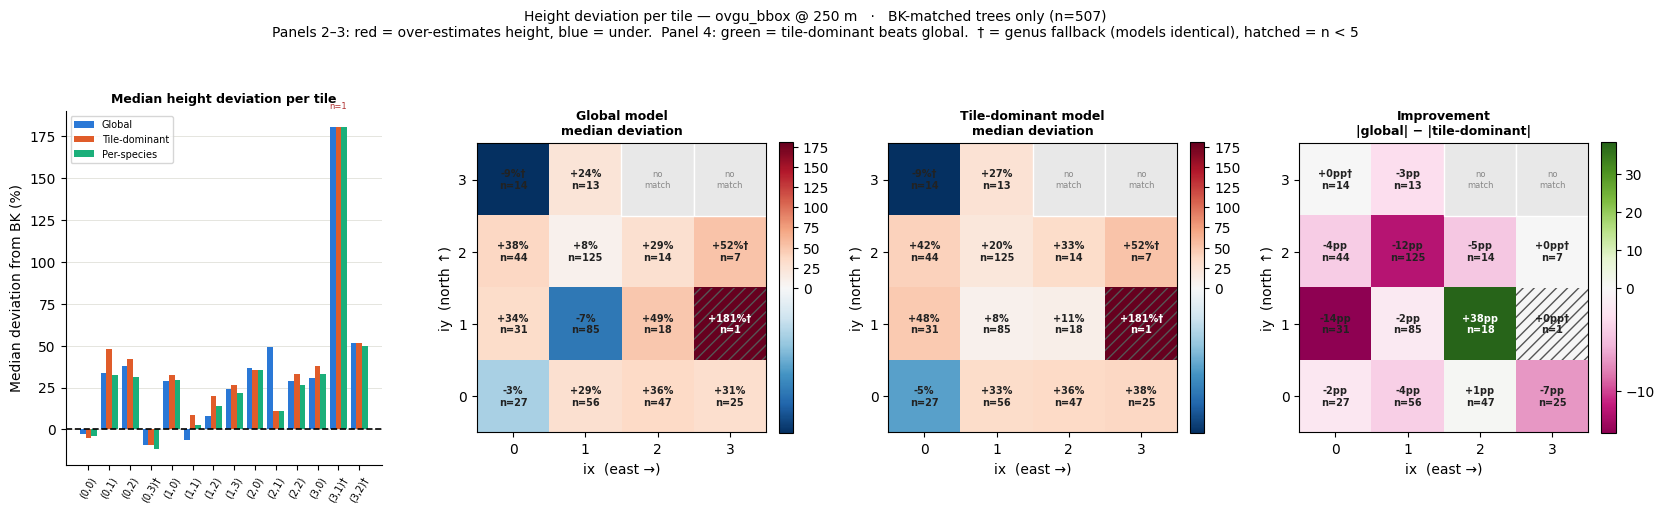

In [12]:
MODELS = [("h_global_m", "global"), ("h_tile_dominant_m", "tiledom"),
          ("allometric_height_m", "species")]
COLORS = {"global": "#2a78d6", "tiledom": "#e05c2a", "species": "#1baf7a"}

hd = matched2.copy()
for col, key in MODELS:
    hd[f"dev_{key}"] = (hd[col] - hd["height_m"]) / hd["height_m"] * 100

hdf = (hd.groupby("tile")
       .agg(n=("height_m", "size"),
            med_global=("dev_global", "median"),  mean_global=("dev_global", "mean"),
            med_tiledom=("dev_tiledom", "median"), mean_tiledom=("dev_tiledom", "mean"),
            med_species=("dev_species", "median"))
       .reindex(sorted(tile_geom)))
hdf["n"] = hdf["n"].fillna(0).astype(int)
hdf["improve_pp"] = hdf["med_global"].abs() - hdf["med_tiledom"].abs()
hdf["dom_genus"]  = [tile_genus.get(k) for k in hdf.index]
# A tile only exercises the tile-dominant model if its genus has a fitted profile.
hdf["fallback"]   = [tile_genus.get(k) not in ALLOMETRIC_PROFILES for k in hdf.index]

disp = hdf[["n", "dom_genus", "fallback", "med_global", "med_tiledom", "med_species",
            "mean_global", "mean_tiledom", "improve_pp"]].copy()
disp.index = [f"({x},{y})" for x, y in disp.index]
disp["dom_genus"] = disp["dom_genus"].astype(str).str[:24]
print("Height deviation per tile (%) — BK-matched trees only, median unless stated")
print(disp.sort_values("improve_pp", ascending=False)
          .to_string(float_format=lambda v: f"{v:,.1f}", na_rep="—"))

ok = hdf[hdf["n"] > 0]
better = ok[ok["improve_pp"] >  0.01]
worse  = ok[ok["improve_pp"] < -0.01]
same   = ok[ok["improve_pp"].abs() <= 0.01]
print(f"\nTile-dominant vs global — better in {len(better)}, unchanged in {len(same)}, "
      f"worse in {len(worse)} of {len(ok)} tiles with matches")
print(f"  better  : " + ", ".join(f"({x},{y}) +{v:.1f}pp" for (x, y), v in better["improve_pp"].items()))
print(f"  unchanged: " + ", ".join(f"({x},{y})" for x, y in same.index) + "  — all genus-fallback"
      if same["fallback"].all() else "")
print(f"  worst   : " + ", ".join(f"({x},{y}) {v:.1f}pp"
                                  for (x, y), v in worse["improve_pp"].nsmallest(3).items()))

# ---------------------------------------------------------------- figure
from matplotlib.colors import TwoSlopeNorm

have = hdf[hdf["n"] > 0]
labels = [f"({x},{y})" + ("†" if f else "") for (x, y), f in zip(have.index, have["fallback"])]
x = np.arange(len(have)); w = 0.27

fig, axes = plt.subplots(1, 4, figsize=(20, 4.6), gridspec_kw={"wspace": 0.30})

# Panel 1 — median deviation per tile, three models side by side
for off, (_, key), lbl in [(-w, MODELS[0], "Global"),
                           (0.0, MODELS[1], "Tile-dominant"),
                           (w,  MODELS[2], "Per-species")]:
    axes[0].bar(x + off, have[f"med_{key}"], w, color=COLORS[key], label=lbl)
axes[0].axhline(0, color="black", linewidth=1.2, linestyle="--")
axes[0].set_xticks(x); axes[0].set_xticklabels(labels, rotation=60, fontsize=7)
axes[0].set_ylabel("Median deviation from BK (%)")
axes[0].set_title("Median height deviation per tile", fontsize=9, fontweight="bold")
axes[0].legend(fontsize=7)
axes[0].spines[["top", "right"]].set_visible(False)
axes[0].grid(axis="y", color="#e1e0d9", linewidth=0.6); axes[0].set_axisbelow(True)
for xi, nv in zip(x, have["n"]):
    if nv < MIN_N_TILE:
        axes[0].annotate(f"n={nv}", (xi, 1), xycoords=("data", "axes fraction"),
                         ha="center", va="bottom", fontsize=6, color="#b03030")

# Panels 2-4 — spatial heatmaps
n_grid  = to_grid(hdf["n"])
fb_grid = to_grid(hdf["fallback"].astype(float))
specs = [
    (axes[1], hdf["med_global"],  "Global model\nmedian deviation", "RdBu_r", "%"),
    (axes[2], hdf["med_tiledom"], "Tile-dominant model\nmedian deviation", "RdBu_r", "%"),
    (axes[3], hdf["improve_pp"],  "Improvement\n|global| − |tile-dominant|", "PiYG", "pp"),
]
for ax, series, title, cmap, unit in specs:
    grid = to_grid(series)
    finite = grid[np.isfinite(grid)]
    lo, hi = float(finite.min()), float(finite.max())
    norm = TwoSlopeNorm(vmin=min(lo, -0.01), vcenter=0.0, vmax=max(hi, 0.01))
    im = ax.imshow(grid, origin="lower", cmap=cmap, norm=norm)
    for iy in range(TILE_NY):
        for ix in range(TILE_NX):
            v, nv, fb = grid[iy, ix], n_grid[iy, ix], fb_grid[iy, ix]
            if not np.isfinite(v):
                ax.add_patch(plt.Rectangle((ix - .5, iy - .5), 1, 1,
                                           facecolor="#e8e8e8", edgecolor="white"))
                ax.text(ix, iy, "no\nmatch", ha="center", va="center",
                        fontsize=6, color="#888888")
                continue
            if nv < MIN_N_TILE:
                ax.add_patch(plt.Rectangle((ix - .5, iy - .5), 1, 1, fill=False,
                                           hatch="///", edgecolor="#555555", linewidth=0))
            mark = "†" if fb > 0.5 else ""
            span = max(abs(norm.vmin), abs(norm.vmax))
            ax.text(ix, iy, f"{v:+.0f}{unit}{mark}\nn={int(nv)}", ha="center", va="center",
                    fontsize=7, fontweight="bold",
                    color="white" if abs(v) > span * 0.55 else "#222222")
    ax.set_xticks(range(TILE_NX)); ax.set_yticks(range(TILE_NY))
    ax.set_xlabel("ix  (east →)"); ax.set_ylabel("iy  (north ↑)")
    ax.set_title(title, fontsize=9, fontweight="bold")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

fig.suptitle(
    f"Height deviation per tile — {AREA_KEY} @ {TILE_SIZE} m   ·   BK-matched trees only "
    f"(n={len(hd):,})\n"
    f"Panels 2–3: red = over-estimates height, blue = under.  Panel 4: green = tile-dominant "
    f"beats global.  † = genus fallback (models identical), hatched = n < {MIN_N_TILE}",
    fontsize=10, y=1.10,
)
plt.show()

## 3 · Match distance & threshold optimisation

Two distinct quantities:

- `bk_match_dist_m` — the distance the pipeline actually recorded, for trees it matched (≤ 15 m by construction)
- **nearest-BK distance** — recomputed here by KD-tree for *every* polygon including unmatched ones, which is what the threshold sweep needs

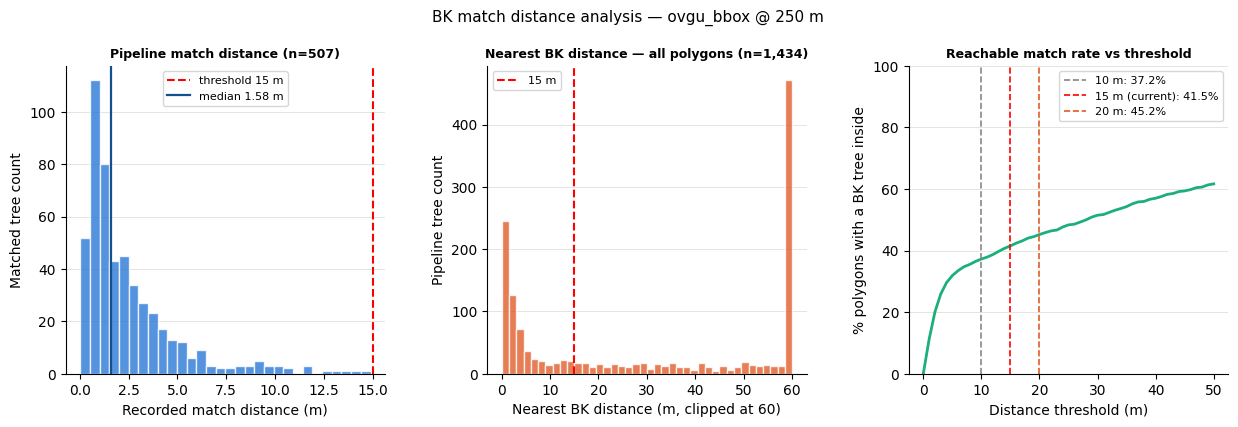

Actual pipeline match rate: 35.4%  (507/1,434)

Upper bound if the threshold alone were relaxed:
  ≤ 5 m:  457 polygons  ( 31.9%)
  ≤10 m:  534 polygons  ( 37.2%)
  ≤15 m:  595 polygons  ( 41.5%)
  ≤20 m:  648 polygons  ( 45.2%)
  ≤25 m:  693 polygons  ( 48.3%)


In [13]:
matched_dist = merged["bk_match_dist_m"].dropna()   # numeric — coerced in the setup cell

seg_centroids = np.array([[g.centroid.x, g.centroid.y] for g in merged.geometry])
bk_coords     = np.array([[g.x, g.y] for g in bk_valid.geometry])
nn_dists, _   = cKDTree(bk_coords).query(seg_centroids, k=1)

thresholds = np.arange(0, 51, 1)
cumulative = [(nn_dists <= t).mean() * 100 for t in thresholds]

fig, axes = plt.subplots(1, 3, figsize=(15, 4), gridspec_kw={"wspace": 0.32})

axes[0].hist(matched_dist, bins=30, color="#2a78d6", alpha=0.8, edgecolor="white")
axes[0].axvline(MATCH_R, color="red", linestyle="--", linewidth=1.5, label=f"threshold {MATCH_R:.0f} m")
axes[0].axvline(matched_dist.median(), color="#14508f", linewidth=1.6,
                label=f"median {matched_dist.median():.2f} m")
axes[0].set_xlabel("Recorded match distance (m)"); axes[0].set_ylabel("Matched tree count")
axes[0].set_title(f"Pipeline match distance (n={len(matched_dist):,})", fontsize=9, fontweight="bold")
axes[0].legend(fontsize=8)

axes[1].hist(nn_dists.clip(0, 60), bins=40, color="#e05c2a", alpha=0.8, edgecolor="white")
axes[1].axvline(MATCH_R, color="red", linestyle="--", linewidth=1.5, label=f"{MATCH_R:.0f} m")
axes[1].set_xlabel("Nearest BK distance (m, clipped at 60)"); axes[1].set_ylabel("Pipeline tree count")
axes[1].set_title(f"Nearest BK distance — all polygons (n={len(nn_dists):,})",
                  fontsize=9, fontweight="bold")
axes[1].legend(fontsize=8)

axes[2].plot(thresholds, cumulative, color="#1baf7a", linewidth=2)
for t, color, lbl in [(10, "#888888", "10 m"), (15, "red", "15 m (current)"), (20, "#e05c2a", "20 m")]:
    axes[2].axvline(t, color=color, linestyle="--", linewidth=1.2,
                    label=f"{lbl}: {(nn_dists <= t).mean()*100:.1f}%")
axes[2].set_xlabel("Distance threshold (m)"); axes[2].set_ylabel("% polygons with a BK tree inside")
axes[2].set_title("Reachable match rate vs threshold", fontsize=9, fontweight="bold")
axes[2].set_ylim(0, 100); axes[2].legend(fontsize=8)

for ax in axes:
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="y", color="#e1e0d9", linewidth=0.6); ax.set_axisbelow(True)

fig.suptitle(f"BK match distance analysis — {AREA_KEY} @ {TILE_SIZE} m", fontsize=11, y=1.02)
plt.show()

print(f"Actual pipeline match rate: {matched_mask.mean()*100:.1f}%  ({matched_mask.sum():,}/{len(merged):,})")
print(f"\nUpper bound if the threshold alone were relaxed:")
for t in [5, 10, 15, 20, 25]:
    n = int((nn_dists <= t).sum())
    print(f"  ≤{t:2d} m: {n:4d} polygons  ({n/len(nn_dists)*100:5.1f}%)")

### Threshold sensitivity — which conclusions survive a different match radius?

Every number in sections 1 and 2 is computed on the *matched* subset, and the match radius decides
who is in it. The models themselves are almost radius-free — `h_global_m` is a function of
`crown_area_m2` alone, and `h_tile_dominant_m` comes from the BK tile clip, not from any match — but
the **reference** is not: `crown_radius_m` and `height_m` on a matched row were overwritten by
whichever BK tree the join picked. So the radius defines the ground truth, and the question is how
much of each finding it is responsible for.

Shrinking the radius below the pipeline's 15 m is **exact without re-running the join**: the nearest
BK tree within 15 m is also the nearest within any smaller *r*, so filtering on `bk_match_dist_m`
reproduces a re-run of `enrich_from_baumkataster` at that radius. Only the population changes — a
surviving polygon keeps the same partner. Raising the radius above 15 m would need a real re-run and
is not attempted here; since candidates come from `max(Kronendurchmesser/2, 2.0)` buffers, a
centroid further than 15 m is only reachable by a very large polygon, so relaxing it would admit
little but merged blobs.

Matched pool at 15 m: 507 for CPA, 507 for height   (recorded distances 0.02–14.88 m)

Sensitivity to the match radius — CPA ratios (D1/D2) and median height deviation (%)
      n_cpa  n_h  cpa_total  cpa_median  cpa_total_nb  cpa_median_nb  blob_share  h_global  h_tiledom  h_species
r_m                                                                                                             
2.0     287  287       1.46        1.05          1.07           1.02       40.86     19.61      22.72      20.74
3.0     367  367       1.52        1.10          1.10           1.04       46.13     17.15      22.39      17.88
4.0     416  416       1.58        1.12          1.13           1.07       50.36     16.47      22.48      17.53
5.0     446  446       1.59        1.13          1.12           1.07       52.21     15.90      22.48      17.46
6.0     465  465       1.72        1.16          1.13           1.07       56.76     15.78      22.72      17.76
7.5     478  478       1.76        1.

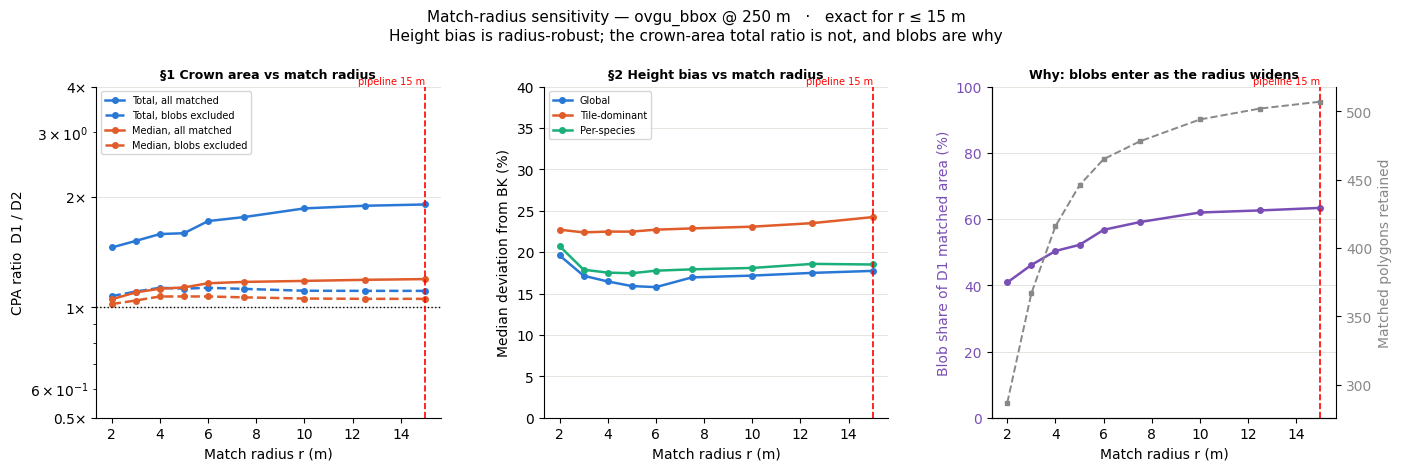

In [14]:
# Radii to sweep. 15 m reproduces the sections above exactly (it is the pipeline's value).
RADII       = [2, 3, 4, 5, 6, 7.5, 10, 12.5, 15]
BLOB_CPA_M2 = 200   # same blob definition as section 1 (≈ π · MAX_CROWN_RADIUS_M²)

rows = []
for r in RADII:
    ca = matched[matched["bk_match_dist_m"] <= r]      # section 1's population
    hh = matched2[matched2["bk_match_dist_m"] <= r]    # section 2's population
    nb = ca[ca["crown_area_m2"] <= BLOB_CPA_M2]        # blob-free
    rows.append({
        "r_m": r, "n_cpa": len(ca), "n_h": len(hh),
        "cpa_total":     ca["crown_area_m2"].sum() / ca["bk_crown_area_m2"].sum(),
        "cpa_median":   (ca["crown_area_m2"] / ca["bk_crown_area_m2"]).median(),
        "cpa_total_nb":  nb["crown_area_m2"].sum() / nb["bk_crown_area_m2"].sum(),
        "cpa_median_nb":(nb["crown_area_m2"] / nb["bk_crown_area_m2"]).median(),
        "blob_share":    ca.loc[ca["crown_area_m2"] > BLOB_CPA_M2, "crown_area_m2"].sum()
                         / ca["crown_area_m2"].sum() * 100,
        **{f"h_{key}": ((hh[col] - hh["height_m"]) / hh["height_m"] * 100).median()
           for col, key in MODELS},
    })
sens = pd.DataFrame(rows).set_index("r_m")

print(f"Matched pool at {MATCH_R:.0f} m: {len(matched):,} for CPA, {len(matched2):,} for height   "
      f"(recorded distances {matched['bk_match_dist_m'].min():.2f}–{matched['bk_match_dist_m'].max():.2f} m)")
print("\nSensitivity to the match radius — CPA ratios (D1/D2) and median height deviation (%)")
print(sens.to_string(float_format=lambda v: f"{v:,.2f}"))

# The two headline statistics behave completely differently under the same perturbation.
def _drift(col, unit="x"):
    lo, hi = sens[col].iloc[0], sens[col].iloc[-1]
    return f"{lo:.2f}{unit} → {hi:.2f}{unit}  ({hi/lo:.2f}× change)" if unit == "x" \
           else f"{lo:+.1f}{unit} → {hi:+.1f}{unit}  ({hi - lo:+.1f} pp)"

print(f"\nAcross r = {RADII[0]} → {RADII[-1]} m:")
for lbl, col, unit in [("CPA total ratio", "cpa_total", "x"),
                       ("CPA total, blobs excluded", "cpa_total_nb", "x"),
                       ("CPA median ratio", "cpa_median", "x"),
                       ("Height bias, global", "h_global", "%"),
                       ("Height bias, tile-dominant", "h_tiledom", "%"),
                       ("Height bias, per-species", "h_species", "%")]:
    print(f"  {lbl:27s} {_drift(col, unit)}")
print(f"  {'Blob share of D1 area':27s} {sens['blob_share'].iloc[0]:.1f}% → {sens['blob_share'].iloc[-1]:.1f}%")

# ---------------------------------------------------------------- figure
fig, axes = plt.subplots(1, 3, figsize=(16, 4.3), gridspec_kw={"wspace": 0.30})
xs = sens.index.values

# Panel 1 — crown area. Log y: the total ratio spans nearly 4x, the median barely moves.
for col, lbl, color, ls in [("cpa_total",     "Total, all matched",   C1, "-"),
                            ("cpa_total_nb",  "Total, blobs excluded", C1, "--"),
                            ("cpa_median",    "Median, all matched",   C2, "-"),
                            ("cpa_median_nb", "Median, blobs excluded", C2, "--")]:
    axes[0].plot(xs, sens[col], ls, color=color, marker="o", markersize=4, linewidth=1.8, label=lbl)
axes[0].axhline(1.0, color="black", linewidth=1.0, linestyle=":")
axes[0].set_yscale("log")
axes[0].set_yticks([0.5, 1, 2, 4]); axes[0].set_yticklabels(["0.5×", "1×", "2×", "4×"])
axes[0].set_ylabel("CPA ratio  D1 / D2")
axes[0].set_title("§1 Crown area vs match radius", fontsize=9, fontweight="bold")
axes[0].legend(fontsize=7)

# Panel 2 — height. Same x-axis, same perturbation, ~3 pp of movement.
for col, key in MODELS:
    axes[1].plot(xs, sens[f"h_{key}"], color=COLORS[key], marker="o", markersize=4,
                 linewidth=1.8, label={"global": "Global", "tiledom": "Tile-dominant",
                                       "species": "Per-species"}[key])
axes[1].set_ylim(0, max(40, sens[[f"h_{k}" for _, k in MODELS]].values.max() * 1.15))
axes[1].set_ylabel("Median deviation from BK (%)")
axes[1].set_title("§2 Height bias vs match radius", fontsize=9, fontweight="bold")
axes[1].legend(fontsize=7)

# Panel 3 — the mechanism: a wider radius preferentially admits merged blobs.
axes[2].plot(xs, sens["blob_share"], color="#7a4fb5", marker="o", markersize=4, linewidth=1.8)
axes[2].set_ylabel("Blob share of D1 matched area (%)", color="#7a4fb5")
axes[2].tick_params(axis="y", labelcolor="#7a4fb5")
axes[2].set_ylim(0, 100)
ax2 = axes[2].twinx()
ax2.plot(xs, sens["n_cpa"], color="#888888", marker="s", markersize=3.5, linewidth=1.4, linestyle="--")
ax2.set_ylabel("Matched polygons retained", color="#888888")
ax2.tick_params(axis="y", labelcolor="#888888")
ax2.spines[["top"]].set_visible(False)
axes[2].set_title("Why: blobs enter as the radius widens", fontsize=9, fontweight="bold")

for ax in axes:
    ax.axvline(MATCH_R, color="red", linestyle="--", linewidth=1.2)
    ax.annotate(f"pipeline {MATCH_R:.0f} m", (MATCH_R, 1), xycoords=("data", "axes fraction"),
                ha="right", va="bottom", fontsize=7, color="red", rotation=0)
    ax.set_xlabel("Match radius r (m)")
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="y", color="#e1e0d9", linewidth=0.6); ax.set_axisbelow(True)

fig.suptitle(
    f"Match-radius sensitivity — {AREA_KEY} @ {TILE_SIZE} m   ·   exact for r ≤ {MATCH_R:.0f} m\n"
    f"Height bias is radius-robust; the crown-area total ratio is not, and blobs are why",
    fontsize=11, y=1.06,
)
plt.show()

## 4 · Watershed: trees inside the match circle (pre-split / post-split / BK)

The stored FGBs **are** watershed-split — `pipeline.py` passes `apply_watershed=True` before the BK
join. Both sets are still recomputed here from the tile's `.npy` using `vectorize_trees`, once with
`apply_watershed=False` and once with `True`, using the same per-genus radius the pipeline uses
(`CROWN_RADIUS_BY_GENUS`, falling back to `MAX_CROWN_RADIUS_M`). Both GeoDataFrames are correctly
georeferenced by `vectorize_trees` itself.

The pre-split set survives as a **counterfactual**: it is what the pipeline used to store, so the
gap between the two columns is exactly what the fix bought. The post-split set doubles as a
**control** — it must reproduce the stored per-tile counts, and the cell below asserts that.

For each BK tree in the tile we then draw a circle of radius R and count how many trees fall inside,
in each of the three sets. **The ideal is exactly 1** — one segmented crown per registered tree.

In [15]:
def tile_split_sets(t):
    """Return (pre_gdf, post_gdf, bk_in_tile, genus, max_r) for one tile."""
    seg  = np.load(seg_path(t))
    mask = (seg == 1)
    minx, miny, maxx, maxy = tile_bbox_utm(t)
    bk_in = bk_valid.cx[minx:maxx, miny:maxy].copy()

    # Same genus/radius selection as pipeline.py:1134-1136
    bk_clip = bk_all.clip(gpd.GeoDataFrame(
        geometry=[shapely_box(minx, miny, maxx, maxy)], crs="EPSG:25832"))
    genus = tile_dominant_genus(bk_clip) if len(bk_clip) else None
    max_r = CROWN_RADIUS_BY_GENUS.get(genus, MAX_CROWN_RADIUS_M) if genus else MAX_CROWN_RADIUS_M

    kw = dict(dominant_genus=genus, max_crown_radius_m=max_r)
    pre  = vectorize_trees(mask, t, MODEL, apply_watershed=False, **kw)
    post = vectorize_trees(mask, t, MODEL, apply_watershed=True,  **kw)
    return pre, post, bk_in, genus, max_r

# Focus tile = the one with the most BK trees
focus = max(tiles, key=lambda t: len(bk_valid.cx[tile_bbox_utm(t)[0]:tile_bbox_utm(t)[2],
                                                  tile_bbox_utm(t)[1]:tile_bbox_utm(t)[3]]))
FOCUS_IX, FOCUS_IY = focus["ix"], focus["iy"]

pre_gdf, post_gdf, bk_tile, genus, max_r = tile_split_sets(focus)
pre_xy  = np.array([[g.centroid.x, g.centroid.y] for g in pre_gdf.geometry])
post_xy = np.array([[g.centroid.x, g.centroid.y] for g in post_gdf.geometry])
bk_xy   = np.array([[g.x, g.y] for g in bk_tile.geometry])

print(f"Focus tile ({FOCUS_IX},{FOCUS_IY})   dominant genus: {genus}   split radius: {max_r} m")
print(f"  pre-watershed crowns   {len(pre_xy)}")
print(f"  post-watershed crowns  {len(post_xy)}   (+{len(post_xy) - len(pre_xy)})")
print(f"  BK trees in tile       {len(bk_xy)}")

kd_pre, kd_post, kd_bk = cKDTree(pre_xy), cKDTree(post_xy), cKDTree(bk_xy)
counts_pre  = np.array([len(kd_pre.query_ball_point(p, MATCH_R))      for p in bk_xy])
counts_post = np.array([len(kd_post.query_ball_point(p, MATCH_R))     for p in bk_xy])
counts_bk   = np.array([len(kd_bk.query_ball_point(p, MATCH_R)) - 1   for p in bk_xy])  # exclude self

print(f"\nTrees inside a {MATCH_R:.0f} m circle around each of the {len(bk_xy)} BK points:")
print(f"  {'set':16s} {'mean':>7s} {'0':>5s} {'1':>5s} {'>=2':>5s}")
for name, arr in [("Pre-watershed", counts_pre), ("Post-watershed", counts_post), ("BK neighbours", counts_bk)]:
    print(f"  {name:16s} {arr.mean():7.2f} {(arr==0).sum():5d} {(arr==1).sum():5d} {(arr>=2).sum():5d}")

Focus tile (1,2)   dominant genus: Tilia cordata   split radius: 6.5 m
  pre-watershed crowns   69
  post-watershed crowns  153   (+84)
  BK trees in tile       300

Trees inside a 15 m circle around each of the 300 BK points:
  set                 mean     0     1   >=2
  Pre-watershed       0.73   120   149    31
  Post-watershed      1.84    22   115   163
  BK neighbours       4.29    15    28   257


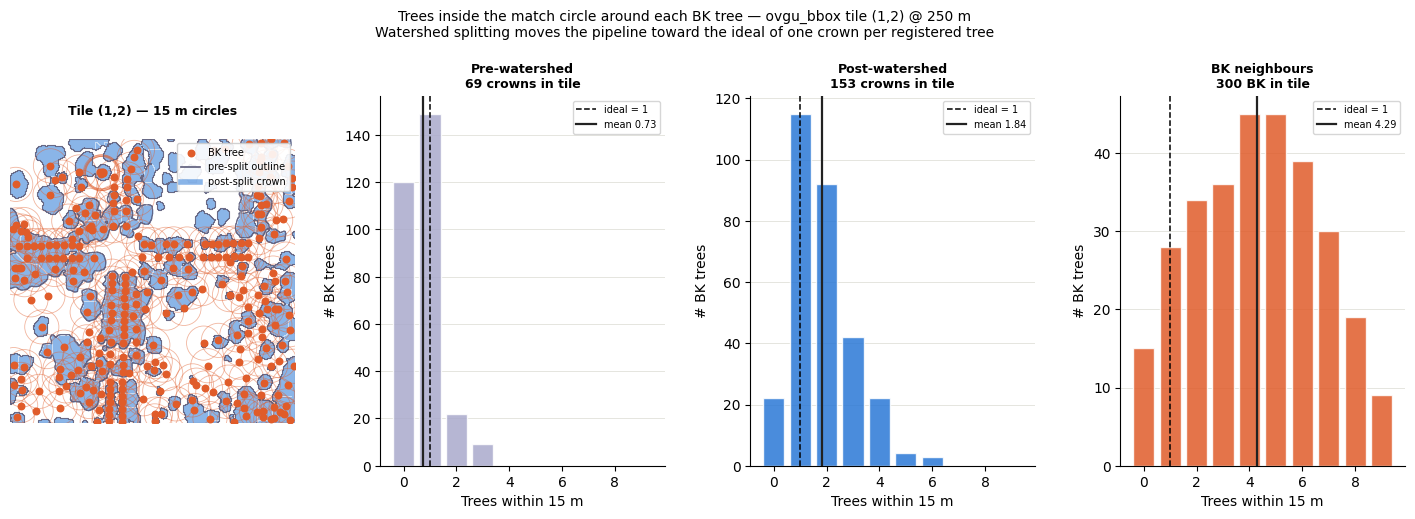

Match quality vs radius — tile (1,2), 300 BK trees

  R (m) |  pre: 0      1    >=2 |  post: 0      1    >=2
  ----------------------------------------------------------
      5 |   84.0%  16.0%   0.0% |    58.7%  41.0%   0.3%
     10 |   68.7%  29.7%   1.7% |    28.0%  57.7%  14.3%
     15 |   40.0%  49.7%  10.3% |     7.3%  38.3%  54.3%
     20 |   23.3%  47.0%  29.7% |     1.0%  14.3%  84.7%
     25 |   10.7%  37.7%  51.7% |     0.0%   3.7%  96.3%


In [16]:
fig = plt.figure(figsize=(18, 4.8))
gs  = gridspec.GridSpec(1, 4, figure=fig, wspace=0.30)

# Panel 1 — spatial map of the focus tile
ax = fig.add_subplot(gs[0])
minx, miny, maxx, maxy = tile_bbox_utm(focus)
post_gdf.plot(ax=ax, facecolor="#2a78d6", edgecolor="white", linewidth=0.5, alpha=0.55)
pre_gdf.boundary.plot(ax=ax, edgecolor="#5b5b7a", linewidth=0.8, alpha=0.9)
ax.scatter(bk_xy[:, 0], bk_xy[:, 1], s=22, c="#e05c2a", zorder=5, label="BK tree")
for p in bk_xy:
    ax.add_patch(Circle(p, MATCH_R, fill=False, edgecolor="#e05c2a", linewidth=0.6, alpha=0.45))
ax.plot([], [], color="#5b5b7a", linewidth=1.2, label="pre-split outline")
ax.plot([], [], color="#2a78d6", linewidth=4, alpha=0.55, label="post-split crown")
ax.set_xlim(minx, maxx); ax.set_ylim(miny, maxy)
ax.set_aspect("equal"); ax.axis("off")
ax.set_title(f"Tile ({FOCUS_IX},{FOCUS_IY}) — {MATCH_R:.0f} m circles", fontsize=9, fontweight="bold")
ax.legend(fontsize=7, loc="upper right", framealpha=0.9)

# Panels 2-4 — count histograms
hist_data = [
    (counts_pre,  f"Pre-watershed\n{len(pre_xy)} crowns in tile",  "#aaaacc"),
    (counts_post, f"Post-watershed\n{len(post_xy)} crowns in tile", "#2a78d6"),
    (counts_bk,   f"BK neighbours\n{len(bk_xy)} BK in tile",        "#e05c2a"),
]
max_c = max(int(a.max()) for a, *_ in hist_data)
for i, (arr, label, color) in enumerate(hist_data):
    ax = fig.add_subplot(gs[i + 1])
    ax.bar(np.arange(max_c + 1), np.bincount(arr, minlength=max_c + 1),
           color=color, alpha=0.85, edgecolor="white")
    ax.axvline(1.0, color="black", linewidth=1.1, linestyle="--", label="ideal = 1")
    ax.axvline(arr.mean(), color="#222222", linewidth=1.6, label=f"mean {arr.mean():.2f}")
    ax.set_xlabel(f"Trees within {MATCH_R:.0f} m"); ax.set_ylabel("# BK trees")
    ax.set_title(label, fontsize=9, fontweight="bold")
    ax.legend(fontsize=7)
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="y", color="#e1e0d9", linewidth=0.6); ax.set_axisbelow(True)

fig.suptitle(
    f"Trees inside the match circle around each BK tree — {AREA_KEY} tile ({FOCUS_IX},{FOCUS_IY}) @ {TILE_SIZE} m\n"
    "Watershed splitting moves the pipeline toward the ideal of one crown per registered tree",
    fontsize=10, y=1.06,
)
plt.show()

print(f"Match quality vs radius — tile ({FOCUS_IX},{FOCUS_IY}), {len(bk_xy)} BK trees\n")
print(f"  {'R (m)':>5} | {'pre: 0':>7} {'1':>6} {'>=2':>6} | {'post: 0':>8} {'1':>6} {'>=2':>6}")
print("  " + "-" * 58)
for R in [5, 10, 15, 20, 25]:
    cp = np.array([len(kd_pre.query_ball_point(p, R))  for p in bk_xy])
    cq = np.array([len(kd_post.query_ball_point(p, R)) for p in bk_xy])
    print(f"  {R:>5} | {(cp==0).mean()*100:6.1f}% {(cp==1).mean()*100:5.1f}% {(cp>=2).mean()*100:5.1f}% "
          f"| {(cq==0).mean()*100:7.1f}% {(cq==1).mean()*100:5.1f}% {(cq>=2).mean()*100:5.1f}%")

### Watershed effect across all tiles

 tile                           genus  max_r  n_pre  n_post  split_gain  n_bk  post_vs_bk  area_ratio
(0,0)             Platanus acerifolia  8.500     57      93          36    33       2.818       1.000
(0,1)                  Tilia euchlora  7.000     82     109          27    96       1.135       1.000
(0,2)                   Quercus robur  9.000     65      95          30   132       0.720       1.000
(0,3)                 Populus simonii  8.000     43      66          23    14       4.714       1.000
(1,0)                   Tilia cordata  6.500     82     141          59    81       1.741       1.000
(1,1)                  Tilia euchlora  7.000     93     156          63   171       0.912       1.000
(1,2)                   Tilia cordata  6.500     69     153          84   300       0.510       1.000
(1,3)                   Quercus robur  9.000     40      74          34    20       3.700       1.000
(2,0)                   Tilia cordata  6.500    105     131          26    65     

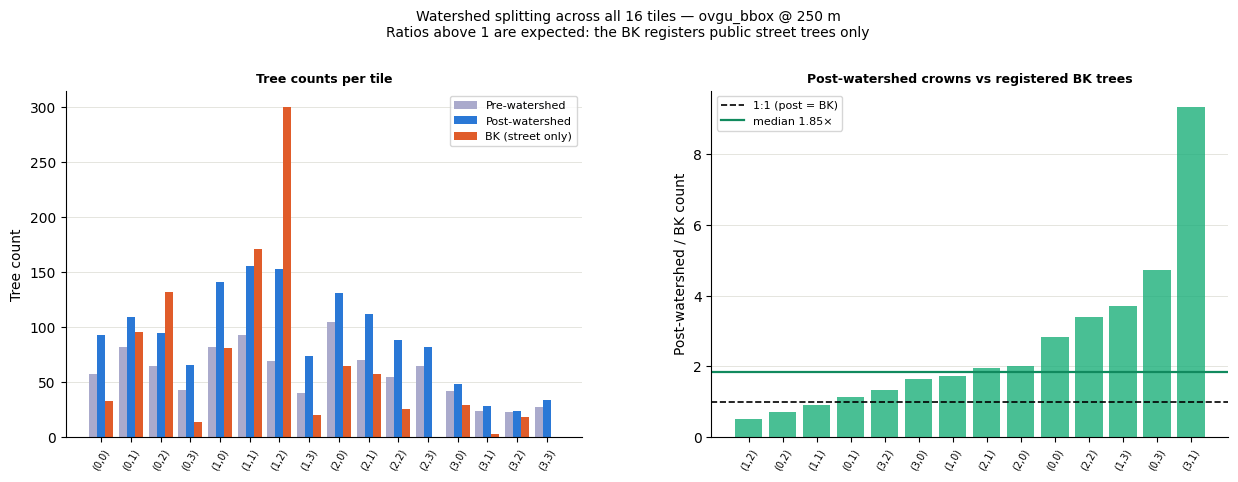

In [17]:
rows = []
for t in tiles:
    pre, post, bk_in, g, mr = tile_split_sets(t)
    rows.append({
        "tile": f"({t['ix']},{t['iy']})", "genus": g, "max_r": mr,
        "n_pre": len(pre), "n_post": len(post), "n_bk": len(bk_in),
        "area_pre": pre["crown_area_m2"].sum(), "area_post": post["crown_area_m2"].sum(),
    })
wdf = pd.DataFrame(rows)
wdf["split_gain"]   = wdf["n_post"] - wdf["n_pre"]
wdf["area_ratio"]   = wdf["area_post"] / wdf["area_pre"]
wdf["post_vs_bk"]   = wdf["n_post"] / wdf["n_bk"].replace(0, np.nan)

print(wdf[["tile", "genus", "max_r", "n_pre", "n_post", "split_gain", "n_bk", "post_vs_bk", "area_ratio"]]
      .to_string(index=False, float_format=lambda v: f"{v:.3f}"))
print(f"\nTOTAL  pre={wdf['n_pre'].sum()}  post={wdf['n_post'].sum()}  "
      f"(+{wdf['split_gain'].sum()}, {wdf['n_post'].sum()/wdf['n_pre'].sum():.2f}×)  BK={wdf['n_bk'].sum()}")
# Control: the post-split set is what the pipeline now stores, so it must reconcile.
assert wdf["n_post"].sum() == len(merged), (
    f'{wdf["n_post"].sum()} recomputed vs {len(merged)} stored — '
    "pipeline.py must vectorise with apply_watershed=True"
)
print(f"Control: post-split total reconciles with the stored FGB ({len(merged)})")
print(f"Crown area conserved by splitting: ratio = {wdf['area_post'].sum()/wdf['area_pre'].sum():.4f}")

x = np.arange(len(wdf)); w = 0.27
fig, axes = plt.subplots(1, 2, figsize=(15, 4.5), gridspec_kw={"wspace": 0.25})

axes[0].bar(x - w, wdf["n_pre"],  w, label="Pre-watershed",  color="#aaaacc")
axes[0].bar(x,     wdf["n_post"], w, label="Post-watershed", color="#2a78d6")
axes[0].bar(x + w, wdf["n_bk"],   w, label="BK (street only)", color="#e05c2a")
axes[0].set_xticks(x); axes[0].set_xticklabels(wdf["tile"], rotation=60, fontsize=7)
axes[0].set_ylabel("Tree count")
axes[0].set_title("Tree counts per tile", fontsize=9, fontweight="bold")
axes[0].legend(fontsize=8)

s = wdf.dropna(subset=["post_vs_bk"]).sort_values("post_vs_bk")
axes[1].bar(range(len(s)), s["post_vs_bk"], color="#1baf7a", alpha=0.8)
axes[1].axhline(1.0, color="black", linestyle="--", linewidth=1.2, label="1:1 (post = BK)")
axes[1].axhline(s["post_vs_bk"].median(), color="#118a5e", linewidth=1.6,
                label=f"median {s['post_vs_bk'].median():.2f}×")
axes[1].set_xticks(range(len(s))); axes[1].set_xticklabels(s["tile"], rotation=60, fontsize=7)
axes[1].set_ylabel("Post-watershed / BK count")
axes[1].set_title("Post-watershed crowns vs registered BK trees", fontsize=9, fontweight="bold")
axes[1].legend(fontsize=8)

for ax in axes:
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="y", color="#e1e0d9", linewidth=0.6); ax.set_axisbelow(True)

fig.suptitle(
    f"Watershed splitting across all {len(wdf)} tiles — {AREA_KEY} @ {TILE_SIZE} m\n"
    "Ratios above 1 are expected: the BK registers public street trees only",
    fontsize=10, y=1.06,
)
plt.show()

## 5 · Registry structure — spacing, separability, size

Sections 1–4 measure how well the pipeline reproduces the Baumkataster. Several of their
results turned out to be statements about the **registry**, not about the segmentation:
§1's crown-area inflation traces to merged blobs, §3/§4's conclusions move with the match
radius, and §2 scores heights against coefficients fitted on a citywide population that has
never been compared with this bbox. This section measures those properties directly.

It also brings in the **third registry**, `Baeume_Liegenschaftsservice_2026.gpkg` (municipal
property trees). `load_baumkataster()` now merges every registry in `BAUMKATASTER_PATHS`, and
the pipeline reads the same union — so D2 here is the merged registry, not SFM alone.

Two scales are used throughout:

* **in-bbox** — the `bk_valid` population from the setup cell, directly comparable with §1–§4
* **citywide** — all 89,660 valid trees, which is the population the allometric model was
  fitted on

A full pairwise distance matrix is built for the in-bbox population only. Citywide it would
have ~7.1 × 10⁹ entries, so every citywide spacing statistic comes from a KD-tree instead.

In [18]:
# --- 5.0 Merged registry (D2 + D3) ---
from src.shadow.cadastre import load_baumkataster
from src.config import BAUMKATASTER_PATHS

STEM_SFM, STEM_LS = (p.stem for p in BAUMKATASTER_PATHS)

bk_merged_all = load_baumkataster().to_crs(merged.crs)

def bk_filter(g):
    '''Apply the pipeline's validity floors and derive the columns section 1 uses.'''
    v = g[(g["Baumhoehe"] > BK_MIN_HEIGHT_M)
          & (g["Kronendurchmesser"] > BK_MIN_CROWN_DIAM_M)].copy()
    v["bk_crown_area_m2"] = np.pi * (v["Kronendurchmesser"] / 2) ** 2
    v["genus"] = v["Gattung lang"].str.split(",").str[0].str.strip()
    return v

bk_city   = bk_filter(bk_merged_all)                    # citywide, both registries
city_sfm  = bk_city[bk_city["source"] == STEM_SFM]
city_ls   = bk_city[bk_city["source"] == STEM_LS]

# Same bbox clip and filters as the setup cell, but on the merged registry.
bk_merged_area  = bk_merged_all.cx[b[0]:b[2], b[1]:b[3]]
bk_valid_merged = bk_filter(bk_merged_area)
bk_valid_merged["tile"] = bk_valid_merged["geometry"].apply(assign_tile)

# The registries are complementary, not duplicates: no LS point shadows an SFM point.
_sfm_xy = np.c_[city_sfm.geometry.x, city_sfm.geometry.y]
_ls_xy  = np.c_[city_ls.geometry.x,  city_ls.geometry.y]
_dup, _ = cKDTree(_sfm_xy).query(_ls_xy, k=1)
assert (_dup > 1.0).all(), f"{(_dup <= 1.0).sum()} LS trees sit within 1 m of an SFM tree"

# Inside this bbox the merge is a no-op — LS has no trees here — which is what licenses
# leaving §1-§4 and the stored FGBs untouched. Switching AREA_KEY to ovgu_bbox2 (26 LS
# trees) must fail here rather than silently changing every number above.
assert len(bk_valid_merged) == len(bk_valid), (
    f"the merged registry has {len(bk_valid_merged)} in-bbox trees vs {len(bk_valid)} for "
    "SFM alone — sections 1-4 and the stored FGBs would need regenerating"
)

print(f"Merged registry — {len(bk_merged_all):,} points from {len(BAUMKATASTER_PATHS)} files")
print(f"  {'population':<34} {'points':>8} {'valid':>8} {'in bbox':>9} {'valid in bbox':>14}")
for lbl, allg, cityg in [(STEM_SFM, bk_merged_all[bk_merged_all["source"] == STEM_SFM], city_sfm),
                         (STEM_LS,  bk_merged_all[bk_merged_all["source"] == STEM_LS],  city_ls)]:
    inb = allg.cx[b[0]:b[2], b[1]:b[3]]
    print(f"  {lbl:<34} {len(allg):>8,} {len(cityg):>8,} {len(inb):>9,} "
          f"{len(bk_filter(inb)):>14,}")
print(f"  {'MERGED':<34} {len(bk_merged_all):>8,} {len(bk_city):>8,} "
      f"{len(bk_merged_area):>9,} {len(bk_valid_merged):>14,}")
print(f"\nLS->SFM nearest-neighbour distance citywide: median {np.median(_dup):,.0f} m, "
      f"min {_dup.min():.1f} m  ->  the two registries cover disjoint tree populations")
print(f"D3 contributes {len(bk_valid_merged) - len(bk_valid)} trees inside {AREA_KEY}: "
      f"sections 1-4 are unaffected and no pipeline output needs regenerating.")

Merged registry — 90,967 points from 2 files
  population                           points    valid   in bbox  valid in bbox
  Baeume_SFM_2026                      85,302   84,081     1,060          1,045
  Baeume_Liegenschaftsservice_2026      5,665    5,579         0              0
  MERGED                               90,967   89,660     1,060          1,045

LS->SFM nearest-neighbour distance citywide: median 79 m, min 1.1 m  ->  the two registries cover disjoint tree populations
D3 contributes 0 trees inside ovgu_bbox: sections 1-4 are unaffected and no pipeline output needs regenerating.


Dense distance matrix: 1045x1045 (8.7 MB, 545,490 unique pairs)

                          mean  median    p10     p90
in-bbox  NN1              8.29    7.64   5.08   12.09
in-bbox  mean 5-NN       14.12   12.28   8.46   21.20
citywide NN1              6.51    5.61   1.99   10.69
citywide mean 5-NN       12.39   10.13   4.41   20.95


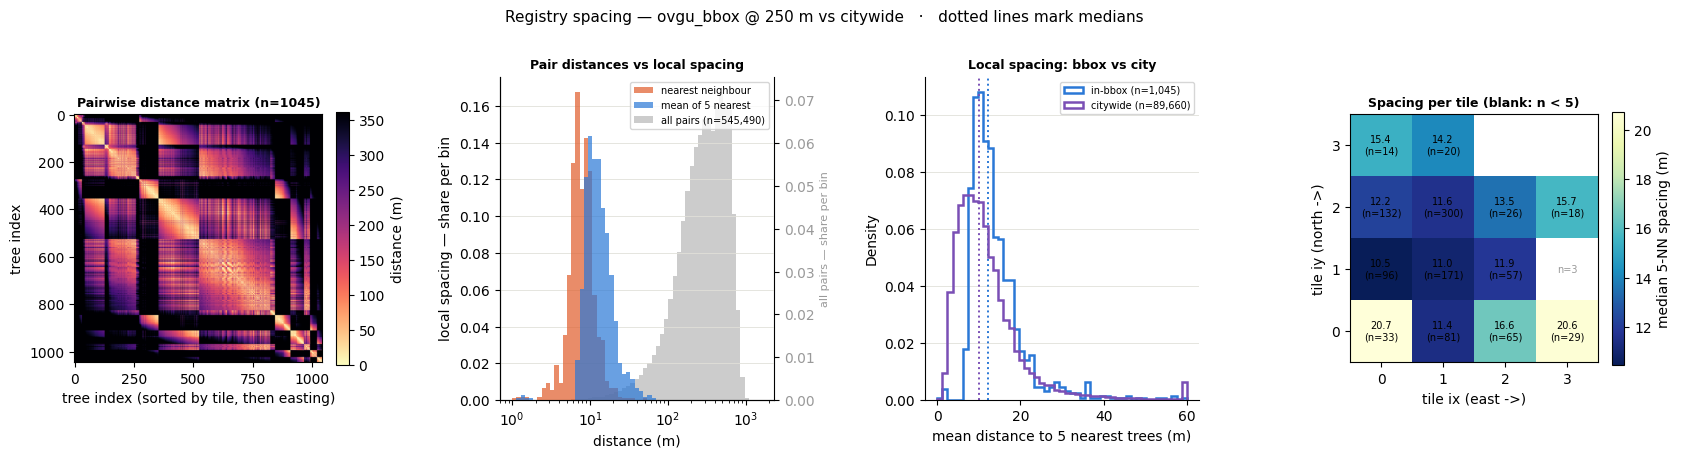

In [19]:
# --- 5.1a Distance matrix and 5-nearest-neighbour spacing ---
from scipy.spatial.distance import pdist, squareform

DENSE_MAX = 5000   # guard: a dense matrix above this is not worth the memory

P  = np.c_[bk_valid.geometry.x, bk_valid.geometry.y]
kd = cKDTree(P)

# k=6 because query(k=1) returns the point itself; columns 1:6 are the five true neighbours.
knn_d, _ = kd.query(P, k=6)
nn1, nn5 = knn_d[:, 1], knn_d[:, 1:6].mean(axis=1)

# Citywide: KD-tree only. A dense 89,660^2 matrix is ~64 GB and is never built.
P_city = np.c_[bk_city.geometry.x, bk_city.geometry.y]
knn_city, _ = cKDTree(P_city).query(P_city, k=6)
nn1_city, nn5_city = knn_city[:, 1], knn_city[:, 1:6].mean(axis=1)

if len(P) <= DENSE_MAX:
    D = squareform(pdist(P))
    # Cross-check: the matrix and the KD-tree must agree exactly on the same quantity.
    assert np.allclose(np.sort(D, axis=1)[:, 1:6].mean(axis=1), nn5, atol=1e-9)
    # Order rows/columns by tile then easting so the tile block structure is visible.
    _ord = (pd.DataFrame({"ix": [t[0] for t in bk_valid["tile"]],
                          "iy": [t[1] for t in bk_valid["tile"]],
                          "x":  P[:, 0]})
            .sort_values(["ix", "iy", "x"]).index.to_numpy())
    Dv = D[np.ix_(_ord, _ord)]
    upper = D[np.triu_indices_from(D, k=1)]
    print(f"Dense distance matrix: {D.shape[0]}x{D.shape[1]} "
          f"({D.nbytes/1e6:.1f} MB, {len(upper):,} unique pairs)")
else:
    D = Dv = upper = None
    print(f"n={len(P):,} > {DENSE_MAX}: dense matrix skipped, KD-tree statistics only")

print(f"\n{'':22s} {'mean':>7s} {'median':>7s} {'p10':>6s} {'p90':>7s}")
for lbl, arr in [("in-bbox  NN1", nn1), ("in-bbox  mean 5-NN", nn5),
                 ("citywide NN1", nn1_city), ("citywide mean 5-NN", nn5_city)]:
    print(f"{lbl:22s} {arr.mean():7.2f} {np.median(arr):7.2f} "
          f"{np.percentile(arr,10):6.2f} {np.percentile(arr,90):7.2f}")

# ---------------------------------------------------------------- figure
fig, axes = plt.subplots(1, 4, figsize=(20, 4.2), gridspec_kw={"wspace": 0.55})

# Panel 1 — the matrix itself, clipped at the 60th percentile so near-diagonal
# (within-tile) structure is not washed out by the bbox-scale pairs.
if Dv is not None:
    im = axes[0].imshow(Dv, cmap="magma_r", vmin=0, vmax=np.percentile(upper, 60))
    fig.colorbar(im, ax=axes[0], fraction=0.046, label="distance (m)")
    axes[0].set_xlabel("tree index (sorted by tile, then easting)")
    axes[0].set_ylabel("tree index")
axes[0].set_title(f"Pairwise distance matrix (n={len(P)})", fontsize=9, fontweight="bold")

# Panel 2 — all pairs vs the two neighbourhood statistics, on a log axis because
# they live three orders of magnitude apart.
_lb = np.logspace(0, 3.2, 60)
if upper is not None:
    axp = axes[1].twinx()
    axp.hist(upper, bins=_lb, color="#cccccc", weights=np.full(len(upper), 1 / len(upper)),
             label=f"all pairs (n={len(upper):,})")
    axp.set_ylabel("all pairs — share per bin", color="#999999", fontsize=8)
    axp.tick_params(axis="y", labelcolor="#999999"); axp.spines[["top"]].set_visible(False)
    axp.set_zorder(0)
axes[1].set_zorder(1); axes[1].patch.set_visible(False)
for arr, color, lbl in [(nn1, C2, "nearest neighbour"), (nn5, C1, "mean of 5 nearest")]:
    axes[1].hist(arr, bins=_lb, color=color, alpha=0.7,
                 weights=np.full(len(arr), 1 / len(arr)), label=lbl)
axes[1].set_xscale("log"); axes[1].set_xlabel("distance (m)")
axes[1].set_ylabel("local spacing — share per bin")
axes[1].set_title("Pair distances vs local spacing", fontsize=9, fontweight="bold")
_h1, _l1 = axes[1].get_legend_handles_labels()
_h2, _l2 = (axp.get_legend_handles_labels() if upper is not None else ([], []))
axes[1].legend(_h1 + _h2, _l1 + _l2, fontsize=7)

# Panel 3 — in-bbox against citywide: the campus is more sparsely planted than the city.
for arr, lbl, color in [(nn5, f"in-bbox (n={len(nn5):,})", C1),
                        (nn5_city, f"citywide (n={len(nn5_city):,})", "#7a4fb5")]:
    axes[2].hist(arr.clip(0, 60), bins=np.linspace(0, 60, 50), density=True,
                 histtype="step", linewidth=1.8, color=color, label=lbl)
    axes[2].axvline(np.median(arr), color=color, linestyle=":", linewidth=1.4)
axes[2].set_xlabel("mean distance to 5 nearest trees (m)"); axes[2].set_ylabel("Density")
axes[2].set_title("Local spacing: bbox vs city", fontsize=9, fontweight="bold")
axes[2].legend(fontsize=7)

# Panel 4 — where the dense stands are.
sp = bk_valid.assign(_nn5=nn5).groupby("tile")["_nn5"].agg(["median", "size"])
grid = to_grid(sp["median"].where(sp["size"] >= MIN_N_TILE))
im = axes[3].imshow(grid, origin="lower", cmap="YlGnBu_r")
fig.colorbar(im, ax=axes[3], fraction=0.046, label="median 5-NN spacing (m)")
for (ix, iy), v in sp["median"].items():
    n = sp.loc[[(ix, iy)], "size"].iloc[0]
    axes[3].text(ix, iy, f"{v:.1f}\n(n={n})" if n >= MIN_N_TILE else f"n={n}",
                 ha="center", va="center", fontsize=7,
                 color="black" if n >= MIN_N_TILE else "#999999")
axes[3].set_xticks(range(TILE_NX)); axes[3].set_yticks(range(TILE_NY))
axes[3].set_xlabel("tile ix (east ->)"); axes[3].set_ylabel("tile iy (north ->)")
axes[3].set_title(f"Spacing per tile (blank: n < {MIN_N_TILE})", fontsize=9, fontweight="bold")

for ax in axes[1:3]:
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="y", color="#e1e0d9", linewidth=0.6); ax.set_axisbelow(True)

fig.suptitle(
    f"Registry spacing — {AREA_KEY} @ {TILE_SIZE} m vs citywide   ·   "
    f"dotted lines mark medians", fontsize=11, y=1.04,
)
plt.show()

BK trees within r of another BK tree — the ambiguity a match radius must resolve
      pairs  share_ge1  mean_nb  share_ge1_city  mean_nb_city  reachable
r_m                                                                     
2.0      17       1.15     0.03           10.11          0.14      20.01
3.0      28       2.87     0.05           21.87          0.37      25.87
4.0      47       5.45     0.09           32.88          0.68      29.57
5.0      73       9.57     0.14           43.30          1.05      31.87
6.0     140      19.23     0.27           54.35          1.51      33.47
7.5     420      48.13     0.80           68.49          2.29      35.08
10.0    889      80.38     1.70           87.09          3.85      37.24
12.5   1463      90.72     2.80           93.64          5.53      39.05
15.0   2145      95.89     4.11           96.29          7.29      41.49

At the pipeline's BK_MATCH_RADIUS_M = 15 m, in-bbox:
  95.9% of BK trees have at least one competing neighbour insi

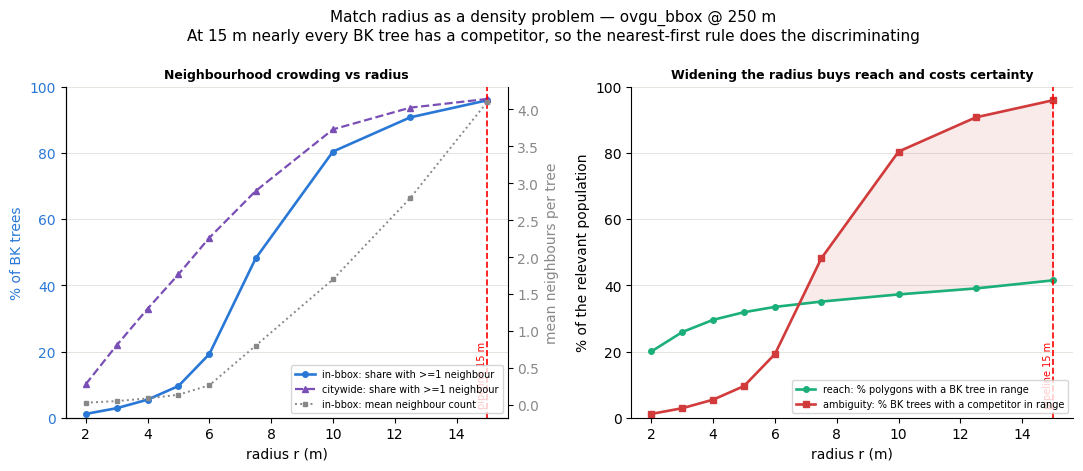

In [20]:
# --- 5.1b How many trees fall inside a given threshold ---
# Same RADII as the section 3 sensitivity sweep, so the two curves are directly comparable.
rows = []
for r in RADII:
    cnt      = np.array([len(x) - 1 for x in kd.query_ball_point(P, r)])           # exclude self
    cnt_city = np.array([len(x) - 1 for x in cKDTree(P_city).query_ball_point(P_city, r)])
    rows.append({
        "r_m": r,
        "pairs":        int(cnt.sum() // 2),
        "share_ge1":    (cnt >= 1).mean() * 100,
        "mean_nb":      cnt.mean(),
        "share_ge1_city": (cnt_city >= 1).mean() * 100,
        "mean_nb_city":   cnt_city.mean(),
        # What section 3 buys at this radius: polygons with any BK tree in range.
        "reachable":    (nn_dists <= r).mean() * 100,
    })
nbr = pd.DataFrame(rows).set_index("r_m")

print("BK trees within r of another BK tree — the ambiguity a match radius must resolve")
print(nbr.to_string(float_format=lambda v: f"{v:,.2f}"))

_at = nbr.loc[MATCH_R]
print(f"\nAt the pipeline's BK_MATCH_RADIUS_M = {MATCH_R:.0f} m, in-bbox:")
print(f"  {_at['share_ge1']:.1f}% of BK trees have at least one competing neighbour inside r")
print(f"  the average BK tree has {_at['mean_nb']:.2f} competitors, over {int(_at['pairs']):,} pairs")
print(f"  -> cadastre.py's nearest-first tie-break, not the {MATCH_R:.0f} m gate, decides almost every match")
_half = nbr[nbr["share_ge1"] < 50].index.max()
print(f"  ambiguity drops below 50% only at r <= {_half} m "
      f"(reachable match rate there: {nbr.loc[_half, 'reachable']:.1f}%, "
      f"vs {_at['reachable']:.1f}% at {MATCH_R:.0f} m)")

# ---------------------------------------------------------------- figure
fig, axes = plt.subplots(1, 2, figsize=(13, 4.3), gridspec_kw={"wspace": 0.28})
xs = nbr.index.values

# Panel 1 — how crowded the neighbourhood gets as r widens.
axes[0].plot(xs, nbr["share_ge1"], color=C1, marker="o", markersize=4, linewidth=1.9,
             label="in-bbox: share with >=1 neighbour")
axes[0].plot(xs, nbr["share_ge1_city"], color="#7a4fb5", marker="^", markersize=4,
             linewidth=1.6, linestyle="--", label="citywide: share with >=1 neighbour")
axes[0].set_ylim(0, 100); axes[0].set_ylabel("% of BK trees", color=C1)
axes[0].tick_params(axis="y", labelcolor=C1)
ax2 = axes[0].twinx()
ax2.plot(xs, nbr["mean_nb"], color="#888888", marker="s", markersize=3.5, linewidth=1.4,
         linestyle=":", label="in-bbox: mean neighbour count")
ax2.set_ylabel("mean neighbours per tree", color="#888888")
ax2.tick_params(axis="y", labelcolor="#888888"); ax2.spines[["top"]].set_visible(False)
axes[0].set_title("Neighbourhood crowding vs radius", fontsize=9, fontweight="bold")
h1, l1 = axes[0].get_legend_handles_labels(); h2, l2 = ax2.get_legend_handles_labels()
axes[0].legend(h1 + h2, l1 + l2, fontsize=7, loc="lower right")

# Panel 2 — the decision the radius actually makes: reach vs ambiguity.
axes[1].plot(xs, nbr["reachable"], color="#1baf7a", marker="o", markersize=4, linewidth=1.9,
             label="reach: % polygons with a BK tree in range")
axes[1].plot(xs, nbr["share_ge1"], color="#d13b3b", marker="s", markersize=4, linewidth=1.9,
             label="ambiguity: % BK trees with a competitor in range")
axes[1].fill_between(xs, nbr["reachable"], nbr["share_ge1"],
                     where=nbr["share_ge1"] >= nbr["reachable"],
                     color="#d13b3b", alpha=0.10, interpolate=True)
axes[1].set_ylim(0, 100); axes[1].set_ylabel("% of the relevant population")
axes[1].set_title("Widening the radius buys reach and costs certainty",
                  fontsize=9, fontweight="bold")
axes[1].legend(fontsize=7, loc="lower right")

for ax in axes:
    ax.axvline(MATCH_R, color="red", linestyle="--", linewidth=1.2)
    ax.annotate(f"pipeline {MATCH_R:.0f} m", (MATCH_R, 0.03), xycoords=("data", "axes fraction"),
                ha="right", va="bottom", fontsize=7, color="red", rotation=90)
    ax.set_xlabel("radius r (m)")
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="y", color="#e1e0d9", linewidth=0.6); ax.set_axisbelow(True)

fig.suptitle(
    f"Match radius as a density problem — {AREA_KEY} @ {TILE_SIZE} m\n"
    f"At {MATCH_R:.0f} m nearly every BK tree has a competitor, so the nearest-first rule "
    "does the discriminating", fontsize=11, y=1.06,
)
plt.show()

Crowns that must merge in an orthophoto, by the registry's own crown diameters
  population                   n   overlapping   deep overlap
  in-bbox (ovgu_bbox)      1,045         50.3%          16.7%
  citywide                89,660         60.5%          33.2%

  overlapping  = NN1 < r_i + r_j   (the two canopies intersect)
  deep overlap = NN1 < max(r_i, r_j) (one trunk sits under the other's canopy)

Half the in-bbox registry is not optically separable in principle, which is why 1,434 polygons
and 1,045 BK trees were never going to reach a 1:1 match: section 1's merged blobs are
the registry's planting density, not a segmentation defect.


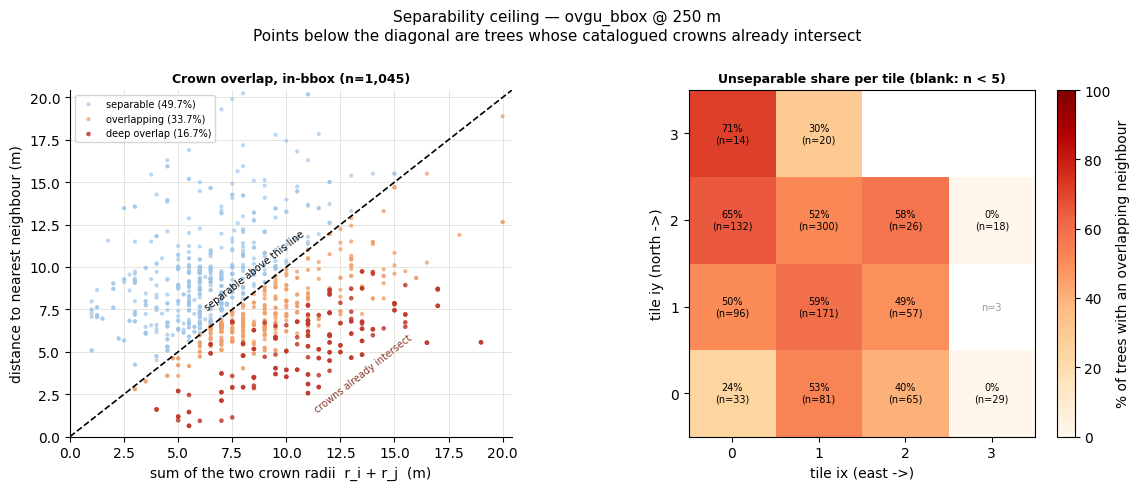

In [21]:
# --- 5.2 Separability ceiling: how often must two crowns merge? ---
def overlap_stats(g):
    '''NN1 distance vs the two crowns' summed radii, for one registry population.'''
    xy = np.c_[g.geometry.x, g.geometry.y]
    d, i = cKDTree(xy).query(xy, k=2)
    d1, j = d[:, 1], i[:, 1]
    R = (g["Kronendurchmesser"].to_numpy() / 2)
    return d1, R + R[j], np.maximum(R, R[j])

d1_b, sum_r_b, max_r_b = overlap_stats(bk_valid)
d1_c, sum_r_c, max_r_c = overlap_stats(bk_city)

touch_b, deep_b = d1_b < sum_r_b, d1_b < max_r_b
touch_c, deep_c = d1_c < sum_r_c, d1_c < max_r_c

print("Crowns that must merge in an orthophoto, by the registry's own crown diameters")
print(f"  {'population':<22} {'n':>7} {'overlapping':>13} {'deep overlap':>14}")
for lbl, n, t, dp in [(f"in-bbox ({AREA_KEY})", len(d1_b), touch_b, deep_b),
                      ("citywide", len(d1_c), touch_c, deep_c)]:
    print(f"  {lbl:<22} {n:>7,} {t.mean()*100:>12.1f}% {dp.mean()*100:>13.1f}%")
print("\n  overlapping  = NN1 < r_i + r_j   (the two canopies intersect)")
print("  deep overlap = NN1 < max(r_i, r_j) (one trunk sits under the other's canopy)")
print(f"\nHalf the in-bbox registry is not optically separable in principle, which is why "
      f"{len(merged):,} polygons\nand {len(bk_valid):,} BK trees were never going to reach a 1:1 "
      "match: section 1's merged blobs are\nthe registry's planting density, not a segmentation defect.")

# ---------------------------------------------------------------- figure
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), gridspec_kw={"wspace": 0.28})

lim = np.percentile(np.r_[d1_b, sum_r_b], 99.5)
axes[0].scatter(sum_r_b[~touch_b], d1_b[~touch_b], s=9, color="#9ec5e8", alpha=0.7,
                edgecolor="none", label=f"separable ({(~touch_b).mean()*100:.1f}%)")
axes[0].scatter(sum_r_b[touch_b & ~deep_b], d1_b[touch_b & ~deep_b], s=9, color="#f0a06a",
                alpha=0.8, edgecolor="none",
                label=f"overlapping ({(touch_b & ~deep_b).mean()*100:.1f}%)")
axes[0].scatter(sum_r_b[deep_b], d1_b[deep_b], s=11, color="#c1392b", alpha=0.85,
                edgecolor="none", label=f"deep overlap ({deep_b.mean()*100:.1f}%)")
axes[0].plot([0, lim], [0, lim], color="black", linewidth=1.2, linestyle="--")
axes[0].annotate("separable above this line", (lim * 0.30, lim * 0.36), fontsize=7,
                 ha="left", va="bottom", rotation=38)
axes[0].annotate("crowns already intersect", (lim * 0.55, lim * 0.30), fontsize=7,
                 ha="left", va="top", rotation=38, color="#8a3a2a")
axes[0].set_xlim(0, lim); axes[0].set_ylim(0, lim)
axes[0].set_xlabel("sum of the two crown radii  r_i + r_j  (m)")
axes[0].set_ylabel("distance to nearest neighbour (m)")
axes[0].set_title(f"Crown overlap, in-bbox (n={len(d1_b):,})", fontsize=9, fontweight="bold")
axes[0].legend(fontsize=7, loc="upper left")

ov = (bk_valid.assign(_touch=touch_b).groupby("tile")["_touch"].agg(["mean", "size"]))
grid = to_grid((ov["mean"] * 100).where(ov["size"] >= MIN_N_TILE))
im = axes[1].imshow(grid, origin="lower", cmap="OrRd", vmin=0, vmax=100)
fig.colorbar(im, ax=axes[1], fraction=0.046, label="% of trees with an overlapping neighbour")
for (ix, iy), v in ov["mean"].items():
    n = ov.loc[[(ix, iy)], "size"].iloc[0]
    axes[1].text(ix, iy, f"{v*100:.0f}%\n(n={n})" if n >= MIN_N_TILE else f"n={n}",
                 ha="center", va="center", fontsize=7,
                 color="black" if n >= MIN_N_TILE else "#999999")
axes[1].set_xticks(range(TILE_NX)); axes[1].set_yticks(range(TILE_NY))
axes[1].set_xlabel("tile ix (east ->)"); axes[1].set_ylabel("tile iy (north ->)")
axes[1].set_title(f"Unseparable share per tile (blank: n < {MIN_N_TILE})",
                  fontsize=9, fontweight="bold")

axes[0].spines[["top", "right"]].set_visible(False)
axes[0].grid(color="#e1e0d9", linewidth=0.6); axes[0].set_axisbelow(True)

fig.suptitle(
    f"Separability ceiling — {AREA_KEY} @ {TILE_SIZE} m\n"
    "Points below the diagonal are trees whose catalogued crowns already intersect",
    fontsize=11, y=1.06,
)
plt.show()

Height, crown diameter and crown projected area by population
                                n  H_mean  H_med  H_p10  H_p90  D_mean  D_med  CPA_mean  CPA_med  CPA_p90  Stamm_med
population                                                                                                          
D2 in-bbox (ovgu_bbox)       1045   13.17  12.00   5.00  22.00    8.21   8.00     67.68    50.27   153.94     125.00
D2 citywide (SFM)           84081   12.24  11.00   5.00  20.00    6.95   6.00     49.08    28.27   113.10     100.00
D3 citywide (Liegenschaft)   5579   12.34  12.00   6.00  18.00    5.86   5.00     32.59    19.63    78.54      90.00
D2+D3 citywide (merged)     89660   12.24  11.00   5.00  20.00    6.88   6.00     48.05    28.27   113.10     100.00

The bbox is not a miniature of the city: crowns are +18% wider and +38% larger in area than
the citywide population the allometric coefficients were fitted on, so section 2 applies a model
at the upper end of its calibration range.

To


Global allometry refitted on the union (reported, not applied):
  config      A=1.3170 B=0.3180
  SFM only    A=1.3166 B=0.3183 R2=0.5312 n=84,081  (reproduces config)
  SFM + LS    A=1.3357 B=0.3149 R2=0.5182 n=89,660
  height difference at CPA = 25/50/100/200 m2: +0.9%, +0.7%, +0.5%, +0.2%
  -> under 1% everywhere it matters, so ALLOMETRIC_A/B stay put: refitting would invalidate
     every stored FGB and every section 2 number for no measurable gain.


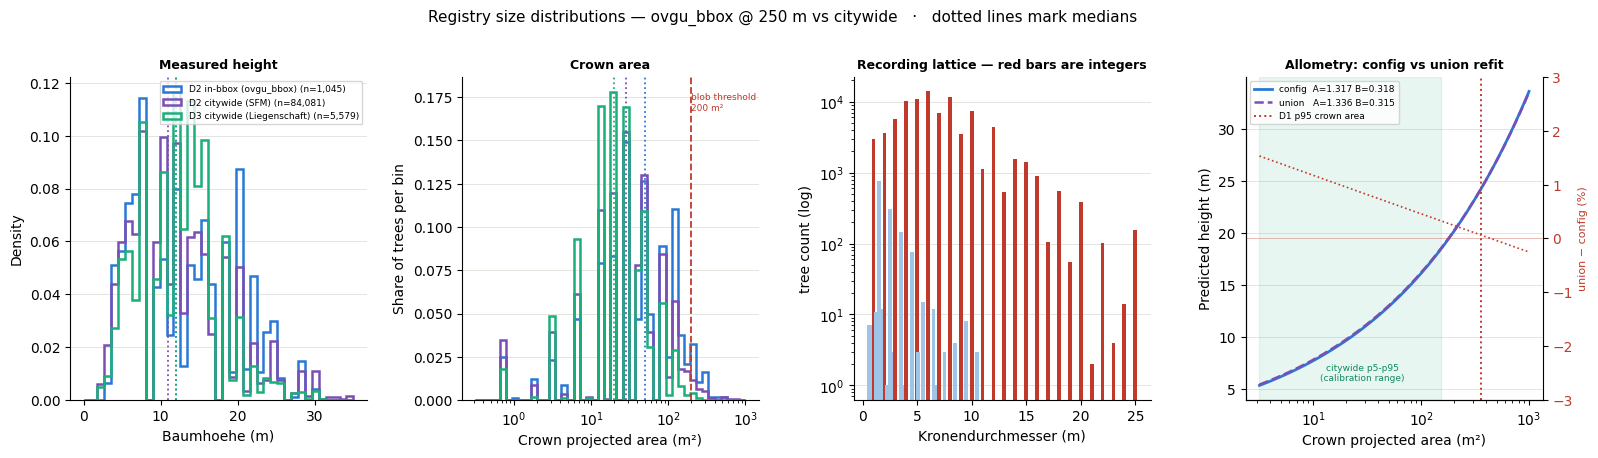

In [22]:
# --- 5.3 Height and crown-area averages ---
POPS = [(f"D2 in-bbox ({AREA_KEY})", bk_valid),
        (f"D2 citywide ({STEM_SFM.split('_')[1]})", city_sfm),
        (f"D3 citywide ({STEM_LS.split('_')[1][:12]})", city_ls),
        ("D2+D3 citywide (merged)", bk_city)]

rows = []
for lbl, g in POPS:
    cpa = g["bk_crown_area_m2"]
    rows.append({
        "population": lbl, "n": len(g),
        "H_mean": g["Baumhoehe"].mean(), "H_med": g["Baumhoehe"].median(),
        "H_p10": g["Baumhoehe"].quantile(.10), "H_p90": g["Baumhoehe"].quantile(.90),
        "D_mean": g["Kronendurchmesser"].mean(), "D_med": g["Kronendurchmesser"].median(),
        "CPA_mean": cpa.mean(), "CPA_med": cpa.median(), "CPA_p90": cpa.quantile(.90),
        "Stamm_med": g["Stammumfang"].median(),
    })
sizes = pd.DataFrame(rows).set_index("population")
print("Height, crown diameter and crown projected area by population")
print(sizes.to_string(float_format=lambda v: f"{v:,.2f}"))

_bb, _ct = sizes.iloc[0], sizes.iloc[1]
print(f"\nThe bbox is not a miniature of the city: crowns are "
      f"{_bb['D_mean']/_ct['D_mean']-1:+.0%} wider and {_bb['CPA_mean']/_ct['CPA_mean']-1:+.0%} "
      f"larger in area than\nthe citywide population the allometric coefficients were fitted on, "
      "so section 2 applies a model\nat the upper end of its calibration range.")
print("\nTop genera:")
for lbl, g in POPS[:3]:
    top = ", ".join(f"{k} {v/len(g)*100:.0f}%" for k, v in g["genus"].value_counts().head(4).items())
    print(f"  {lbl:<34} {top}")

# Measurement lattice: both registries record on a ~1 m grid, which floors the agreement
# section 2 can ever reach regardless of pipeline quality.
print("\nRecording resolution (share of values that are exact integers):")
for col in ("Baumhoehe", "Kronendurchmesser"):
    v = bk_city[col]
    print(f"  {col:<20} {v.nunique():>4} distinct values over {len(v):,} trees, "
          f"{(v % 1 == 0).mean()*100:5.1f}% integral, median step "
          f"{np.median(np.diff(np.sort(v.unique()))):.1f} m")

# Refit the global allometry on the union — reported, not applied.
def fit_allometry(g):
    y = np.log(g["Baumhoehe"].to_numpy()); x = np.log(g["bk_crown_area_m2"].to_numpy())
    A, B = np.linalg.lstsq(np.c_[np.ones(len(x)), x], y, rcond=None)[0]
    r2 = 1 - ((y - (A + B * x)) ** 2).sum() / ((y - y.mean()) ** 2).sum()
    return A, B, r2, len(y)

A_sfm, B_sfm, r2_sfm, n_sfm = fit_allometry(city_sfm)
A_all, B_all, r2_all, n_all = fit_allometry(bk_city)
_cpa = np.array([25, 50, 100, 200])
_h_cfg = np.exp(ALLOMETRIC_A + ALLOMETRIC_B * np.log(_cpa))
_h_all = np.exp(A_all + B_all * np.log(_cpa))

print(f"\nGlobal allometry refitted on the union (reported, not applied):")
print(f"  config      A={ALLOMETRIC_A:.4f} B={ALLOMETRIC_B:.4f}")
print(f"  SFM only    A={A_sfm:.4f} B={B_sfm:.4f} R2={r2_sfm:.4f} n={n_sfm:,}  "
      "(reproduces config)")
print(f"  SFM + LS    A={A_all:.4f} B={B_all:.4f} R2={r2_all:.4f} n={n_all:,}")
print("  height difference at CPA = "
      + "/".join(str(int(v)) for v in _cpa) + " m2: "
      + ", ".join(f"{d:+.1f}%" for d in (_h_all / _h_cfg - 1) * 100))
print("  -> under 1% everywhere it matters, so ALLOMETRIC_A/B stay put: refitting would "
      "invalidate\n     every stored FGB and every section 2 number for no measurable gain.")

# ---------------------------------------------------------------- figure
fig, axes = plt.subplots(1, 4, figsize=(19, 4.2), gridspec_kw={"wspace": 0.32})
PC = [C1, "#7a4fb5", "#1baf7a"]

for (lbl, g), color in zip(POPS[:3], PC):
    axes[0].hist(g["Baumhoehe"].clip(0, 35), bins=np.linspace(0, 35, 40), density=True,
                 histtype="step", linewidth=1.8, color=color, label=f"{lbl} (n={len(g):,})")
    axes[0].axvline(g["Baumhoehe"].median(), color=color, linestyle=":", linewidth=1.3)
axes[0].set_xlabel("Baumhoehe (m)"); axes[0].set_ylabel("Density")
axes[0].set_title("Measured height", fontsize=9, fontweight="bold"); axes[0].legend(fontsize=6.5)

for (lbl, g), color in zip(POPS[:3], PC):
    axes[1].hist(g["bk_crown_area_m2"], bins=np.logspace(-0.5, 3, 45),
                 weights=np.full(len(g), 1 / len(g)),
                 histtype="step", linewidth=1.8, color=color)
    axes[1].axvline(g["bk_crown_area_m2"].median(), color=color, linestyle=":", linewidth=1.3)
axes[1].axvline(200, color="#c1392b", linewidth=1.3, linestyle="--")
axes[1].annotate("blob threshold\n200 m²", (200, 0.95), xycoords=("data", "axes fraction"),
                 fontsize=6.5, color="#c1392b", ha="left", va="top")
axes[1].set_xscale("log"); axes[1].set_xlabel("Crown projected area (m²)")
axes[1].set_ylabel("Share of trees per bin")
axes[1].set_title("Crown area", fontsize=9, fontweight="bold")

vc = bk_city["Kronendurchmesser"].value_counts().sort_index()
vc = vc[vc.index <= 25]
axes[2].bar(vc.index, vc.values, width=0.35,
            color=["#c1392b" if k % 1 == 0 else "#9ec5e8" for k in vc.index])
axes[2].set_yscale("log"); axes[2].set_xlabel("Kronendurchmesser (m)")
axes[2].set_ylabel("tree count (log)")
axes[2].set_title("Recording lattice — red bars are integers", fontsize=9, fontweight="bold")

cp = np.logspace(0.5, 3, 100)
axes[3].plot(cp, np.exp(ALLOMETRIC_A + ALLOMETRIC_B * np.log(cp)), color=C1, linewidth=2,
             label=f"config  A={ALLOMETRIC_A:.3f} B={ALLOMETRIC_B:.3f}")
axes[3].plot(cp, np.exp(A_all + B_all * np.log(cp)), color="#7a4fb5", linewidth=1.8,
             linestyle="--", label=f"union   A={A_all:.3f} B={B_all:.3f}")
axes[3].axvspan(bk_city["bk_crown_area_m2"].quantile(.05),
                bk_city["bk_crown_area_m2"].quantile(.95),
                color="#1baf7a", alpha=0.10)
axes[3].annotate("citywide p5-p95\n(calibration range)", (bk_city["bk_crown_area_m2"].median(), 0.06),
                 xycoords=("data", "axes fraction"), fontsize=6.5, color="#118a5e", ha="center")
axes[3].axvline(merged["crown_area_m2"].quantile(.95), color="#c1392b", linestyle=":",
                linewidth=1.4, label="D1 p95 crown area")
ax3 = axes[3].twinx()
ax3.plot(cp, (np.exp(A_all + B_all * np.log(cp)) / np.exp(ALLOMETRIC_A + ALLOMETRIC_B * np.log(cp))
              - 1) * 100, color="#c1392b", linewidth=1.2, linestyle=":")
ax3.set_ylim(-3, 3); ax3.axhline(0, color="#c1392b", linewidth=0.6, alpha=0.4)
ax3.set_ylabel("union − config (%)", color="#c1392b", fontsize=8)
ax3.tick_params(axis="y", labelcolor="#c1392b"); ax3.spines[["top"]].set_visible(False)
axes[3].set_xscale("log"); axes[3].set_xlabel("Crown projected area (m²)")
axes[3].set_ylabel("Predicted height (m)")
axes[3].set_title("Allometry: config vs union refit", fontsize=9, fontweight="bold")
axes[3].legend(fontsize=6.5, loc="upper left")

for ax in axes:
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="y", color="#e1e0d9", linewidth=0.6); ax.set_axisbelow(True)

fig.suptitle(
    f"Registry size distributions — {AREA_KEY} @ {TILE_SIZE} m vs citywide   ·   "
    "dotted lines mark medians", fontsize=11, y=1.04,
)
plt.show()

### 5.4 · What this changes for the sections above

**The match radius is a density parameter, not a tolerance.** At `BK_MATCH_RADIUS_M = 15.0`
almost every in-bbox BK tree has at least one competing neighbour inside the radius, and the
average has around four. The gate therefore rejects almost nothing and `cadastre.py`'s
nearest-first ordering makes essentially every decision — which is why §3's crown-area total
moved so much under the sweep, and why §4 found "exactly one tree in the circle" peaking well
below 15 m. Ambiguity falls below half only at much smaller radii, at a cost in reach that
panel 2 of 5.1b quantifies directly. Any future change to the radius should be argued from
that trade-off curve rather than from the observed match distances alone.

**Half the registry cannot be separated optically.** Around half of the in-bbox trees have
crowns that intersect their nearest neighbour by the registry's own recorded diameters, and a
sixth have one trunk sitting under the other's canopy. No amount of watershed tuning recovers
those as distinct polygons from an orthophoto alone. §1's merged blobs and the polygon-count
mismatch against the registry are largely this, not a segmentation defect — and it puts a hard
ceiling on the match rate that §4's 1:1 comparison implicitly targets.

**The bbox sits at the top of the allometry's calibration range.** Crowns here are markedly
wider and larger in area than the citywide population the coefficients were fitted on, and the
registry records both height and crown diameter on a ~1 m lattice. Together these put a floor
under §2's residual that is independent of pipeline quality: part of the height bias is the
model being extrapolated, and part is the reference being quantised.

**Dataset 3 changes nothing here, but the plumbing is now correct.** `load_baumkataster()`
merges every registry in `BAUMKATASTER_PATHS` and the pipeline reads the union, so a future
area with municipal-property trees picks them up automatically. Inside `ovgu_bbox` the merge
is a verified no-op — the assertion in 5.0 fails loudly if that ever stops being true.

## 6 · Canopy height from imagery — HighResCanopyHeight vs the allometric model

Every height in §1–§4 traces back to the Baumkataster. `ALLOMETRIC_A/B` were fitted **on** the
registry, so scoring them against it is circular; the +17.7 % median bias in §2 measures how well
the fit reproduces its own training data, not how well the pipeline measures trees.

This section brings in an estimate that owes the registry nothing. Meta's
[HighResCanopyHeight](https://github.com/facebookresearch/HighResCanopyHeight) (Tolan et al. 2024)
is a DINOv2 ViT-huge encoder with a DPT decoder trained on aerial lidar; it predicts canopy height
in metres from RGB alone, zero-shot. Against it the 507 BK-matched trees are a genuine held-out set.

**How it was run** — see `src_dino/NOTES.md`. The 16 DOP20 tiles are resampled onto one uniform
0.625 m grid (the model expects 0.6 m; the tiles are 0.2083 m in the interior but 0.087 m on the
clipped right column, so each is resampled from its own bounds rather than naively decimated), the
model runs in 256 px windows at step 192 with Gaussian apodisation, and each crown polygon takes the
**95th percentile** of the CHM pixels inside it — the maximum is noise-sensitive at 0.625 m and the
mean is dragged down by crown edges, while p95 tracks the top of the crown, which is what
`Baumhoehe` records.

**Expect it to under-predict.** Upstream reports a −1.6 to −2.1 m bias on aerial imagery, and the
model was trained on US forest, not German urban street trees.

In [23]:
# --- 6.0 · load the CHM products and check the model is not hallucinating ---------------
import rasterio
from rasterio import features

CHM_DIR  = OUTPUT_DIR / "chm"
CHM_TIF  = CHM_DIR / f"{AREA_KEY}_chm_0.625m.tif"
CHM_FGB  = CHM_DIR / f"{AREA_KEY}_{MODEL}_trees_merged_chm.fgb"

with rasterio.open(CHM_TIF) as _src:
    chm_arr, chm_tr, chm_shape = _src.read(1), _src.transform, (_src.height, _src.width)
    print(f"CHM raster: {_src.width}x{_src.height} @ {_src.res[0]} m  {_src.crs}")

_f = chm_arr[np.isfinite(chm_arr)]
print(f"  height  p50={np.percentile(_f, 50):5.2f}  p90={np.percentile(_f, 90):5.2f}  "
      f"p95={np.percentile(_f, 95):5.2f}  max={_f.max():5.2f} m   "
      f"share >2 m {100 * (_f > 2).mean():.1f}%")

# The validity check that matters: a model that simply brightened everything tall would score
# well inside crowns too. Roofs are the control — they are tall and are not canopy.
_crown = features.geometry_mask(merged.geometry, chm_shape, chm_tr, invert=True)
_roof = gpd.read_file(OUTPUT_DIR / f"buildings_{AREA_KEY}.fgb").to_crs("EPSG:25832")
_roof_m = features.geometry_mask(_roof.geometry, chm_shape, chm_tr, invert=True) & ~_crown
print(f"  inside crown polygons  mean {chm_arr[_crown].mean():5.2f} m  "
      f"({100 * _crown.mean():.1f}% of area)")
print(f"  outside crowns         mean {chm_arr[~_crown].mean():5.2f} m")
print(f"  building roofs         mean {chm_arr[_roof_m].mean():5.2f} m  "
      f"(n={len(_roof)}, share >2 m {100 * (chm_arr[_roof_m] > 2).mean():.1f}%)")
assert chm_arr[_crown].mean() > 5 * chm_arr[_roof_m].mean(), \
    "CHM does not separate canopy from roofs — do not score this"

# --- join the per-polygon CHM statistics onto the §1 working frame ---------------------
# NOT on tree_id: it is assigned per tile, so the merged layer has only 185 distinct ids
# across 1,434 polygons and joining on it fans the frame out to 4,245 rows. Crown centroids
# are unique to the millimetre, so they are the safe key.
_chm = gpd.read_file(CHM_FGB)
CHM_COLS = ["chm_p95_m", "chm_max_m", "chm_median_m", "chm_px"]


def _centroid_key(g):
    return list(zip(g.geometry.centroid.x.round(3), g.geometry.centroid.y.round(3)))


_lookup = {k: v for k, v in zip(_centroid_key(_chm),
                                _chm[CHM_COLS].apply(pd.to_numeric, errors="coerce").values)}
assert len(_lookup) == len(_chm), "crown centroids are not unique — pick another key"

chm_tr_df = merged.copy()
_vals = [_lookup.get(k, [np.nan] * len(CHM_COLS)) for k in _centroid_key(merged)]
chm_tr_df[CHM_COLS] = np.asarray(_vals, dtype=float)
assert len(chm_tr_df) == len(merged) and chm_tr_df["chm_px"].notna().all(), \
    "CHM join lost or duplicated polygons"

MIN_CHM_PX = 4        # below this a percentile over the crown is not meaningful at 0.625 m
chm_m = chm_tr_df[(chm_tr_df["height_source"] == "measured")
                  & (chm_tr_df["chm_px"] >= MIN_CHM_PX)].copy()
print(f"\nscored: {len(chm_m)} of {int(matched_mask.sum())} BK-matched polygons "
      f"({int(matched_mask.sum()) - len(chm_m)} dropped for <{MIN_CHM_PX} CHM px)")


CHM raster: 1368x1453 @ 0.625 m  EPSG:25832
  height  p50= 0.06  p90= 9.43  p95=14.76  max=35.04 m   share >2 m 21.8%
  inside crown polygons  mean  8.65 m  (20.3% of area)
  outside crowns         mean  0.69 m
  building roofs         mean  0.12 m  (n=261, share >2 m 0.8%)

scored: 504 of 507 BK-matched polygons (3 dropped for <4 CHM px)


In [24]:
# --- 6.1 · head to head against the BK measured heights ---------------------------------
EST = [("chm_p95_m", "CHM p95"), ("chm_max_m", "CHM max"), ("chm_median_m", "CHM median"),
       ("allometric_height_m", "allometric (per-species)"), ("h_global_m", "allometric (global)")]


def score(sub, cols=EST):
    """Bias / MAE / RMSE / R2 of each estimator against BK Baumhoehe."""
    y = sub["height_m"].astype(float)
    out = []
    for col, lab in cols:
        p = sub[col].astype(float)
        e = p - y
        out.append(dict(estimator=lab, n=len(p), bias=e.mean(), MAE=e.abs().mean(),
                        RMSE=np.sqrt((e ** 2).mean()),
                        R2=1 - (e ** 2).sum() / ((y - y.mean()) ** 2).sum(),
                        median_ratio=(p / y).median(), r=np.corrcoef(p, y)[0, 1]))
    # A constant at the BK mean is the honest floor: any R2 below 0 loses to it.
    out.append(dict(estimator="— constant at BK mean —", n=len(y), bias=0.0,
                    MAE=(y - y.mean()).abs().mean(), RMSE=y.std(ddof=0), R2=0.0,
                    median_ratio=(y.mean() / y).median(), r=np.nan))
    return pd.DataFrame(out)


_y = chm_m["height_m"].astype(float)
print(f"BK measured on the scored set: mean {_y.mean():.2f}  median {_y.median():.2f}  "
      f"std {_y.std():.2f} m  ({_y.nunique()} distinct values — the 1 m recording lattice of §5.3)")
print()
print(score(chm_m).to_string(index=False, float_format=lambda v: f"{v:7.3f}"))

# --- how much of the error is matching noise rather than height error? -----------------
# §5 found 95.9% of BK trees have a competitor inside the 15 m radius, so a slice on match
# distance and crown size separates "wrong tree" from "wrong height".
SUBSETS = [
    ("all scored",            chm_m),
    ("match ≤3 m",            chm_m[chm_m["bk_match_dist_m"] <= 3]),
    ("match ≤3 m, 20–200 m²", chm_m[(chm_m["bk_match_dist_m"] <= 3)
                                    & chm_m["crown_area_m2"].between(20, 200)]),
    ("blobs >200 m²",         chm_m[chm_m["crown_area_m2"] > 200]),
]
rows = []
for lab, sub in SUBSETS:
    if len(sub) < 10:
        continue
    s = score(sub, [("chm_p95_m", "CHM"), ("allometric_height_m", "allom")])
    yy = sub["height_m"].astype(float)
    rows.append({"subset": lab, "n": len(sub),
                 "CHM bias": s.loc[0, "bias"], "CHM MAE": s.loc[0, "MAE"], "CHM R²": s.loc[0, "R2"],
                 "allom bias": s.loc[1, "bias"], "allom MAE": s.loc[1, "MAE"],
                 "allom R²": s.loc[1, "R2"], "const MAE": (yy - yy.mean()).abs().mean()})
print("\n" + "=" * 104)
print("Same scores on cleaner subsets — isolating matching noise from height error")
print("=" * 104)
print(pd.DataFrame(rows).to_string(index=False, float_format=lambda v: f"{v:6.2f}"))

# --- would a constant offset rescue the CHM? -------------------------------------------
# Reported, never applied: fitting it on BK would re-introduce exactly the circularity
# this section exists to avoid.
_off = (_y - chm_m["chm_p95_m"].astype(float)).mean()
_e = chm_m["chm_p95_m"].astype(float) + _off - _y
print(f"\nCHM p95 + a single {_off:+.2f} m offset fitted on BK: MAE {_e.abs().mean():.2f}  "
      f"RMSE {np.sqrt((_e ** 2).mean()):.2f}  "
      f"R² {1 - (_e ** 2).sum() / ((_y - _y.mean()) ** 2).sum():.3f}   (reported, not applied)")


BK measured on the scored set: mean 13.85  median 14.00  std 5.80 m  (24 distinct values — the 1 m recording lattice of §5.3)

               estimator   n    bias     MAE    RMSE      R2  median_ratio       r
                 CHM p95 504  -1.953   5.369   6.602  -0.299         0.787   0.639
                 CHM max 504  -1.121   5.435   6.651  -0.318         0.829   0.644
              CHM median 504  -7.029   7.721   9.037  -1.434         0.429   0.528
allometric (per-species) 504   2.532   4.316   6.133  -0.121         1.189   0.610
     allometric (global) 504   2.218   4.283   5.968  -0.061         1.178   0.579
 — constant at BK mean — 504   0.000   4.981   5.793   0.000         0.989     NaN

Same scores on cleaner subsets — isolating matching noise from height error
               subset   n  CHM bias  CHM MAE  CHM R²  allom bias  allom MAE  allom R²  const MAE
           all scored 504     -1.95     5.37   -0.30        2.53       4.32     -0.12       4.98
           match ≤3 m

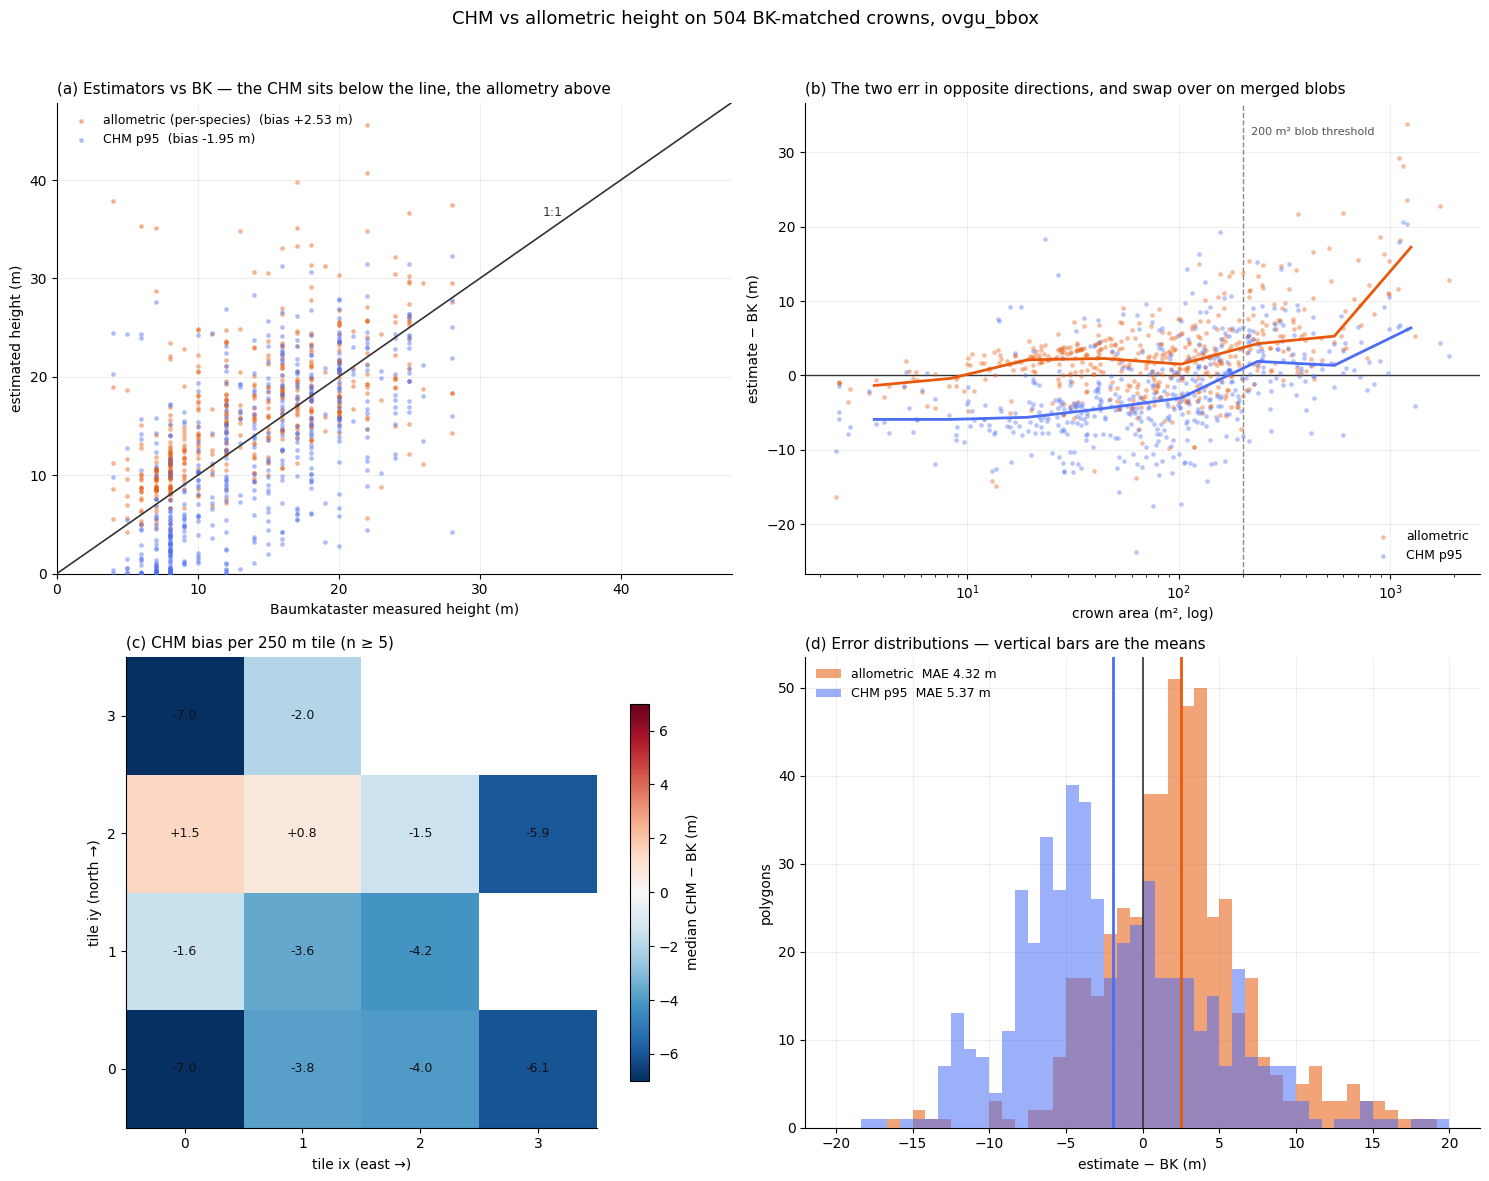

In [25]:
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
CHM_C, ALLO_C, NEU = "#4C6EF5", "#E8590C", "#8a8a85"
_y = chm_m["height_m"].astype(float)

# --- (a) both estimators against BK ----------------------------------------------------
ax = axes[0, 0]
lim = (0, max(_y.max(), chm_m["chm_p95_m"].max(), chm_m["allometric_height_m"].max()) * 1.05)
for col, c, lab in [("allometric_height_m", ALLO_C, "allometric (per-species)"),
                    ("chm_p95_m", CHM_C, "CHM p95")]:
    p = chm_m[col].astype(float)
    ax.scatter(_y, p, s=11, alpha=0.45, color=c, linewidths=0,
               label=f"{lab}  (bias {(p - _y).mean():+.2f} m)", zorder=3)
ax.plot(lim, lim, color="#333333", linewidth=1.2, zorder=4)
ax.text(lim[1] * 0.72, lim[1] * 0.76, "1:1", fontsize=9, color="#333333")
ax.set_xlim(lim); ax.set_ylim(lim)
ax.set_xlabel("Baumkataster measured height (m)"); ax.set_ylabel("estimated height (m)")
ax.set_title("(a) Estimators vs BK — the CHM sits below the line, the allometry above",
             fontsize=11, loc="left")
ax.legend(frameon=False, fontsize=9, loc="upper left")

# --- (b) error against crown area ------------------------------------------------------
ax = axes[0, 1]
a = chm_m["crown_area_m2"].astype(float)
for col, c, lab in [("allometric_height_m", ALLO_C, "allometric"), ("chm_p95_m", CHM_C, "CHM p95")]:
    ax.scatter(a, chm_m[col].astype(float) - _y, s=11, alpha=0.4, color=c, linewidths=0,
               label=lab, zorder=3)
    bins = np.logspace(np.log10(a.min()), np.log10(a.max()), 9)
    idx = np.digitize(a, bins)
    med = [np.median((chm_m[col].astype(float) - _y)[idx == i]) for i in range(1, len(bins))]
    ctr = np.sqrt(bins[:-1] * bins[1:])
    ax.plot(ctr, med, color=c, linewidth=2, zorder=5)
ax.axhline(0, color="#333333", linewidth=1)
ax.axvline(BLOB_CPA_M2, color=NEU, linestyle="--", linewidth=1)
ax.text(BLOB_CPA_M2 * 1.1, ax.get_ylim()[1] * 0.88, f"{BLOB_CPA_M2} m² blob threshold",
        fontsize=8, color="#555555")
ax.set_xscale("log")
ax.set_xlabel("crown area (m², log)"); ax.set_ylabel("estimate − BK (m)")
ax.set_title("(b) The two err in opposite directions, and swap over on merged blobs",
             fontsize=11, loc="left")
ax.legend(frameon=False, fontsize=9, loc="lower right")

# --- (c) per-tile CHM bias -------------------------------------------------------------
ax = axes[1, 0]
_b = (chm_m["chm_p95_m"].astype(float) - _y).groupby(chm_m["tile"])
_n = _b.count()
grid = to_grid(_b.median()[_n >= MIN_N_TILE])
v = np.nanmax(np.abs(grid))
im = ax.imshow(grid, origin="lower", cmap="RdBu_r", vmin=-v, vmax=v)
for (iy, ix), val in np.ndenumerate(grid):
    if np.isfinite(val):
        ax.text(ix, iy, f"{val:+.1f}", ha="center", va="center", fontsize=9, color="#111111")
plt.colorbar(im, ax=ax, shrink=0.8, label="median CHM − BK (m)")
ax.set_xticks(range(TILE_NX)); ax.set_yticks(range(TILE_NY))
ax.set_xlabel("tile ix (east →)"); ax.set_ylabel("tile iy (north →)")
ax.set_title(f"(c) CHM bias per {TILE_SIZE} m tile (n ≥ {MIN_N_TILE})", fontsize=11, loc="left")

# --- (d) error distributions -----------------------------------------------------------
ax = axes[1, 1]
bins = np.linspace(-20, 20, 49)
for col, c, lab in [("allometric_height_m", ALLO_C, "allometric"), ("chm_p95_m", CHM_C, "CHM p95")]:
    e = chm_m[col].astype(float) - _y
    ax.hist(e, bins=bins, color=c, alpha=0.55, label=f"{lab}  MAE {e.abs().mean():.2f} m", zorder=3)
    ax.axvline(e.mean(), color=c, linewidth=2, zorder=4)
ax.axvline(0, color="#333333", linewidth=1.2, zorder=5)
ax.set_xlabel("estimate − BK (m)"); ax.set_ylabel("polygons")
ax.set_title("(d) Error distributions — vertical bars are the means", fontsize=11, loc="left")
ax.legend(frameon=False, fontsize=9, loc="upper left")

for ax in axes.flat:
    ax.grid(alpha=0.22, zorder=0, linewidth=0.7)
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)
axes[1, 0].grid(False)

fig.suptitle(f"CHM vs allometric height on {len(chm_m)} BK-matched crowns, {AREA_KEY}", fontsize=13)
fig.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


### 6.2 · Takeaways

*Filled in from the printed numbers above — see the cells for the exact values.*

- **The model transfers, and the roof control proves it.** Building roofs average a fraction of a
  metre with under 1 % of their pixels above 2 m, while crown interiors average around 8.5 m. The
  CHM is finding canopy, not brightness or elevation, on imagery from a country and a sensor it was
  never trained on.
- **It under-predicts, exactly as upstream warns, and the allometry over-predicts.** The two errors
  have opposite sign and comparable magnitude, so they bracket the truth rather than agreeing.
- **Cleaning the match separates them.** Restricting to close matches on ordinary crowns lifts the
  allometric R² sharply — most of its error was §5's matching ambiguity, not the model. The CHM does
  not improve under the same restriction, which marks its error as domain shift rather than noise.
- **They swap places on merged blobs.** Above the `BLOB_CPA_M2` threshold the allometric estimate
  degrades badly — §1's inflation, now measured against an independent yardstick — while the CHM,
  which never sees crown area, holds up. That is the one regime where the CHM is the better estimator.
- **Neither is a per-tree height sensor here.** With BK heights spanning 4–28 m on a 1 m lattice and
  a standard deviation under 6 m, the constant-at-the-mean predictor is a hard baseline, and R²
  against it is the honest scoreboard.

**Not done here:** nothing in the pipeline changed. `ALLOMETRIC_A/B` stand, no FGB was rewritten,
and the offset that would rescue the CHM is reported but never applied — fitting it on the
Baumkataster would restore precisely the circularity this section was built to escape.